In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---

In [3]:
import zipfile, itertools

zip_path = "/content/drive/MyDrive/dataset_filtrado_drive.zip"

with zipfile.ZipFile(zip_path, "r") as z:
    names = z.namelist()
    print("N files in zip:", len(names))
    print("First 20 names:")
    for n in names[:20]:
        print(n)


N files in zip: 94769
First 20 names:
train/n000002/0018_03.jpg
train/n000002/0027_01.jpg
train/n000002/0032_01.jpg
train/n000002/0051_02.jpg
train/n000002/0093_01.jpg
train/n000002/0098_01.jpg
train/n000002/0150_02.jpg
train/n000002/0153_01.jpg
train/n000002/0171_01.jpg
train/n000002/0218_01.jpg
train/n000003/0012_01.jpg
train/n000003/0027_02.jpg
train/n000003/0033_01.jpg
train/n000003/0049_01.jpg
train/n000003/0068_01.jpg
train/n000003/0095_04.jpg
train/n000003/0167_02.jpg
train/n000003/0202_01.jpg
train/n000003/0220_02.jpg
train/n000004/0008_02.jpg


In [4]:
import pandas as pd

zip_path = "/content/drive/MyDrive/dataset_filtrado_drive.zip"
labels_path = "/content/df_balanced.csv"

df = pd.read_csv(labels_path)
df["Filename"] = df["Filename"].astype(str).str.replace("\\", "/", regex=False)

with zipfile.ZipFile(zip_path, "r") as z:
    zip_canon = set()
    for n in z.namelist():
        if n.lower().endswith(".jpg") and n.startswith("train/"):
            zip_canon.add(n[len("train/"):])

df_ok = df[df["Filename"].isin(zip_canon)].reset_index(drop=True)

print("df original:", len(df))
print("df en zip:", len(df_ok))
print("faltan:", len(df) - len(df_ok))

out_path = "/content/drive/MyDrive/df_balanced_inzip.csv"
df_ok.to_csv(out_path, index=False)
print("Guardado:", out_path)

df original: 100000
df en zip: 94769
faltan: 5231
Guardado: /content/drive/MyDrive/df_balanced_inzip.csv


In [5]:
import os, io, zipfile
import pandas as pd
import numpy as np
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.transforms.v2 as v2
from torchvision.io import decode_image, ImageReadMode
import torch


ATTRS = ['Male', 'Young', 'Senior','Asian', 'Black', 'Smiling',
         'Blond_Hair', 'Chubby', 'Heavy_Makeup','Black_Hair', 'Big_Nose']


class ZipFaceDataset(Dataset):
    def __init__(self, zip_path, labels_path, attrs=ATTRS, img_size=512, zip_prefix="train/"):
        self.zip_path = zip_path
        self.zip_prefix = zip_prefix
        self.attrs = attrs

        if labels_path.endswith(".parquet"):
            df = pd.read_parquet(labels_path)
        else:
            df = pd.read_csv(labels_path)

        assert "Filename" in df.columns, "No encuentro columna Filename"
        self.filenames = df["Filename"].astype(str).tolist()
        self.conds = df[attrs].astype(np.float32).values

        # v2 transforma más rápido y evita el cuello de PIL
        self.tf = v2.Compose([
            v2.Resize((img_size, img_size), interpolation=v2.InterpolationMode.BICUBIC, antialias=True),
            v2.ToDtype(torch.float32, scale=True), # Pasa a [0, 1]
            v2.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]) # Pasa a [-1, 1]
        ])

        self._zip = None

    def _get_zip(self):
        if self._zip is None:
            self._zip = zipfile.ZipFile(self.zip_path, "r")
        return self._zip

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        z = self._get_zip()
        rel = self.filenames[idx].replace("\\", "/")
        zname = f"{self.zip_prefix}{rel}"

        try:
            raw = z.read(zname)
        except KeyError:
            raw = z.read(rel)

        # decodificación nativa a tensor (B, C, H, W) mucho más rápida que PIL
        tensor_img = decode_image(torch.frombuffer(bytearray(raw), dtype=torch.uint8), mode=ImageReadMode.RGB)

        x = self.tf(tensor_img)
        c = torch.from_numpy(self.conds[idx])
        return x, c

In [6]:
zip_path = "/content/drive/MyDrive/dataset_filtrado_drive.zip"
labels_path = "/content/drive/MyDrive/df_balanced_inzip.csv"

dataset = ZipFaceDataset(zip_path, labels_path, img_size=512, zip_prefix="train/")

train_loader = DataLoader(
    dataset,
    batch_size=48,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    drop_last=True,
    persistent_workers=True)

xb, cb = next(iter(train_loader))
print("x:", xb.shape, xb.min().item(), xb.max().item())
print("c:", cb.shape, cb[0])

x: torch.Size([48, 3, 512, 512]) -1.0 1.0
c: torch.Size([48, 11]) tensor([1., 0., 0., 0., 0., 1., 0., 1., 0., 0., 0.])


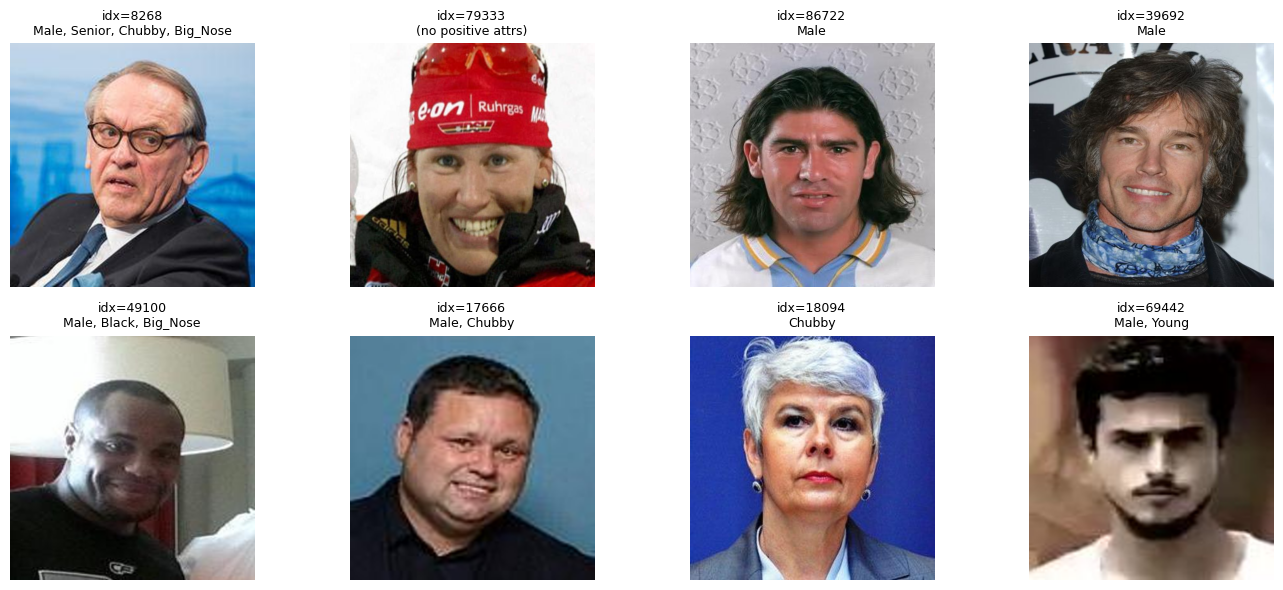

In [45]:
import matplotlib.pyplot as plt


def denorm(x):
    return (x + 1) / 2

def show_samples(ds, attrs, n=8, seed=0):
    rng = np.random.default_rng(seed)
    idxs = rng.choice(len(ds), size=n, replace=False)

    plt.figure(figsize=(14, 6))
    for i, idx in enumerate(idxs, start=1):
        x, c = ds[idx]
        x_show = denorm(x).clamp(0, 1).permute(1, 2, 0).cpu().numpy()

        # atributos activos
        c_np = c.cpu().numpy()
        active = [attrs[j] for j, v in enumerate(c_np) if v > 0.5]
        title = f"idx={idx}\n" + (", ".join(active) if active else "(no positive attrs)")

        plt.subplot(2, (n + 1)//2, i)
        plt.imshow(x_show)
        plt.axis("off")
        plt.title(title, fontsize=9)

    plt.tight_layout()
    plt.show()

show_samples(dataset, ATTRS, n=8, seed=78)

---

# Model

In [7]:
from typing import Literal, Tuple, Optional
import torch
import math
import torch.nn as nn
ScheduleKind = Literal["linear", "cosine"]

def extract(a: torch.Tensor, t: torch.Tensor, x_shape: torch.Size) -> torch.Tensor:
    """
    Toma un vector 1D (longitud T) y lo indexa por t (B,), devolviendo (B, 1, 1, 1)
    broadcastable al tamaño de x.
    """
    t = t.long().clamp_(0, a.shape[0]-1)
    out = a.gather(0, t)
    return out.view((t.shape[0],) + (1,) * (len(x_shape) - 1))

def beta_schedule_linear(T: int, beta_min: float = 1e-4, beta_max: float = 2e-2) -> torch.Tensor:
    """
    Schedule lineal clásico: beta_t en [beta_min, beta_max].
    """
    return torch.linspace(beta_min, beta_max, T, dtype=torch.float32)

def _alpha_bar_cosine(t: torch.Tensor, s: float = 0.008) -> torch.Tensor:
    """
    Alphas-bar continuas según Nichol & Dhariwal (cosine schedule):
        alpha_bar(t) = cos^2( ((t/T + s)/(1+s)) * (pi/2) )
    Asume t ∈ [0, 1]. Retorna alpha_bar(t) ∈ (0,1].
    """
    x = (t + s) / (1.0 + s)
    return torch.cos((math.pi / 2.0) * x).clamp(min=1e-7) ** 2


def beta_schedule_cosine(T: int, s: float = 0.008) -> torch.Tensor:
    """
    Discretiza alpha_bar(t) por diferencias para obtener beta_t.
    """
    steps = torch.arange(T + 1, dtype=torch.float32) / T  # 0..1
    alphas_bar = _alpha_bar_cosine(steps, s=s)
    alphas_bar = alphas_bar / alphas_bar[0]  # normaliza para que alpha_bar(0)=1
    betas = 1 - (alphas_bar[1:] / alphas_bar[:-1])
    return betas.clamp(min=1e-8, max=0.999)

class LabelTokenEncoder(nn.Module):
    """
    c: (B, 11) in {0,1}
    returns tokens: (B, 11, D)
    """
    def __init__(self, num_labels: int = 11, context_dim: int = 256):
        super().__init__()
        self.num_labels = num_labels
        self.context_dim = context_dim

        # token embedding por atributo (cuando está "activo")
        self.attr_embed = nn.Embedding(num_labels, context_dim)
        # token embedding "nulo" por atributo (cuando está apagado o cuando haces CFG-null)
        self.null_embed = nn.Embedding(num_labels, context_dim)

        # ids fijos 0..10 para indexar embeddings
        self.register_buffer("ids", torch.arange(num_labels), persistent=False)

    def forward(self, c: torch.Tensor) -> torch.Tensor:
        """
        c float/bool: (B, 11)
        """
        B = c.shape[0]
        ids = self.ids.unsqueeze(0).expand(B, -1)                 # (B,11)
        e_attr = self.attr_embed(ids)                             # (B,11,D)
        e_null = self.null_embed(ids)                             # (B,11,D)

        c = c.float().unsqueeze(-1)                               # (B,11,1)
        tokens = e_null + c * (e_attr - e_null)                   # (B,11,D)
        return tokens

In [8]:
from typing import Literal, Optional, Callable
import math
import torch
import torch.nn as nn
import torch.nn.functional as F


ScheduleKind = Literal["linear", "cosine"]

class Diffusion(nn.Module):
    """
    DDPM/DDIM utilities (works for pixel-space or latent-space):
      - Precomputes schedules and posterior coefficients
      - q_sample, predict_x0
      - loss (eps prediction)
      - sampling steps (DDPM and DDIM)

    For conditional diffusion (StableDiffusion-like), model_eps_pred_fn should accept:
        eps_pred = model_eps_pred_fn(x_t, t, cond=cond)
    where cond could be:
        - context tokens [B, T, D] for cross-attention, or
        - label vector [B, 11] if your UNet embeds internally
    """
    def __init__(
        self,
        T: int = 1000,
        schedule: ScheduleKind = "linear",
        beta_min: float = 1e-4,
        beta_max: float = 2e-2,
        cosine_s: float = 0.008,
        clamp_x0: bool = True,
        dynamic_threshold: Optional[float] = None,
        img_size=None,
    ):
        super().__init__()
        self.T = int(T)
        self.clamp_x0 = clamp_x0
        self.dynamic_threshold = dynamic_threshold
        self.img_size = img_size

        if schedule == "linear":
            betas = beta_schedule_linear(T, beta_min, beta_max)
        elif schedule == "cosine":
            betas = beta_schedule_cosine(T, s=cosine_s)
        else:
            raise ValueError(f"Unknown schedule: {schedule}")

        alphas = 1.0 - betas
        alphas_cumprod = torch.cumprod(alphas, dim=0)

        self.register_buffer("betas", betas, persistent=False)
        self.register_buffer("alphas", alphas, persistent=False)
        self.register_buffer("alphas_cumprod", alphas_cumprod, persistent=False)
        self.register_buffer("sqrt_alphas_cumprod", torch.sqrt(alphas_cumprod), persistent=False)
        self.register_buffer("sqrt_one_minus_alphas_cumprod", torch.sqrt(1.0 - alphas_cumprod), persistent=False)
        self.register_buffer("alphas_cumprod_prev", F.pad(alphas_cumprod[:-1], (1, 0), value=1.0), persistent=False)

        posterior_variance = betas * (1.0 - self.alphas_cumprod_prev) / (1.0 - self.alphas_cumprod)
        self.register_buffer("posterior_variance", posterior_variance.clamp(min=1e-20), persistent=False)
        self.register_buffer("posterior_log_variance", torch.log(posterior_variance.clamp(min=1e-20)), persistent=False)

        self.register_buffer(
            "posterior_mean_coef1",
            betas * torch.sqrt(self.alphas_cumprod_prev) / (1.0 - self.alphas_cumprod),
            persistent=False
        )
        self.register_buffer(
            "posterior_mean_coef2",
            (1.0 - self.alphas_cumprod_prev) * torch.sqrt(alphas) / (1.0 - self.alphas_cumprod),
            persistent=False
        )

    def sample_timesteps(self, batch_size: int, device=None) -> torch.Tensor:
        if device is None:
            device = self.betas.device
        return torch.randint(1, self.T, (batch_size,), device=device, dtype=torch.long)

    def q_sample(self, x0: torch.Tensor, t: torch.Tensor, eps: Optional[torch.Tensor] = None) -> torch.Tensor:
        if eps is None:
            eps = torch.randn_like(x0)
        sqrt_ab = extract(self.sqrt_alphas_cumprod, t, x0.shape)
        sqrt_omb = extract(self.sqrt_one_minus_alphas_cumprod, t, x0.shape)
        return sqrt_ab * x0 + sqrt_omb * eps

    @torch.no_grad()
    def predict_x0(self, x_t: torch.Tensor, eps_pred: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        sqrt_ab = extract(self.sqrt_alphas_cumprod, t, x_t.shape)
        sqrt_omb = extract(self.sqrt_one_minus_alphas_cumprod, t, x_t.shape)
        x0_hat = (x_t - sqrt_omb * eps_pred) / (sqrt_ab + 1e-12)

        if self.dynamic_threshold is not None:
            s = self.dynamic_threshold
            amax = x0_hat.detach().abs().flatten(1).max(dim=1).values
            amax = torch.maximum(amax, torch.tensor(1.0, device=x0_hat.device, dtype=x0_hat.dtype))
            x0_hat = (x0_hat.transpose(0, 1) / amax.clamp(min=s).unsqueeze(-1).unsqueeze(-1)).transpose(0, 1)
            x0_hat = x0_hat.clamp(-1, 1)
        elif self.clamp_x0:
            x0_hat = x0_hat.clamp(-1, 1)

        return x0_hat

    def posterior_mean_variance(self, x_t: torch.Tensor, x0_hat: torch.Tensor, t: torch.Tensor):
        coef1 = extract(self.posterior_mean_coef1, t, x_t.shape)
        coef2 = extract(self.posterior_mean_coef2, t, x_t.shape)
        mean = coef1 * x0_hat + coef2 * x_t
        var = extract(self.posterior_variance, t, x_t.shape)
        logvar = extract(self.posterior_log_variance, t, x_t.shape)
        return mean, var, logvar


    def get_snr(self, t: torch.Tensor) -> torch.Tensor:
        """
        Calcula la relación señal-ruido (SNR) para un timestep t.
        SNR(t) = alpha_cumprod(t) / (1 - alpha_cumprod(t))
        """
        a_t = extract(self.alphas_cumprod, t, (t.shape[0],))
        return a_t / (1.0 - a_t)

    # -------------------------
    # Training loss (conditional-ready)
    # -------------------------
    def loss_simple(
        self,
        model_eps_pred_fn: Callable,    # (x_t, t, cond) -> eps_pred
        x0: torch.Tensor,
        t: torch.Tensor,
        cond: Optional[torch.Tensor] = None,
        cond_drop_prob: float = 0.0,
        noise: Optional[torch.Tensor] = None,
        weight: Optional[torch.Tensor] = None,
        null_cond: Optional[torch.Tensor] = None,
        use_min_snr: bool = True,       # Activado por defecto para mejor convergencia
        min_snr_gamma: float = 5.0      # Parámetro estándar de la literatura
    ) -> torch.Tensor:

        if noise is None:
            noise = torch.randn_like(x0)

        # CFG dropout
        if cond is not None and cond_drop_prob > 0.0:
            B = x0.shape[0]
            drop_mask = (torch.rand(B, device=x0.device) < cond_drop_prob)

            if null_cond is None:
                null_cond = torch.zeros_like(cond)

            view_shape = (B,) + (1,) * (cond.ndim - 1)
            drop_mask = drop_mask.view(view_shape)
            cond_used = torch.where(drop_mask, null_cond, cond)
        else:
            cond_used = cond

        x_t = self.q_sample(x0, t, eps=noise)
        eps_pred = model_eps_pred_fn(x_t, t, cond_used)

        mse = (noise - eps_pred).pow(2).mean(dim=tuple(range(1, eps_pred.ndim)))

        # Ponderación Min-SNR
        if use_min_snr:
            snr = self.get_snr(t).squeeze()
            # Para epsilon-prediction, el peso escalar es min(gamma, SNR) / SNR
            snr_weight = torch.clamp(snr, max=min_snr_gamma)
            min_snr_weight = snr_weight / snr

            # Combinar con cualquier otro peso externo si lo hubiera
            if weight is None:
                weight = min_snr_weight
            else:
                weight = weight * min_snr_weight

        if weight is not None:
            # Asegurar broadcast correcto si weight es 1D (B,)
            if weight.dim() < mse.dim():
                weight = weight.view(-1, *([1] * (mse.dim() - 1)))
            mse = mse * weight

        return mse.mean()

    # -------------------------
    # Sampling steps (conditional-ready)
    # -------------------------
    @torch.no_grad()
    def p_sample_step(
        self,
        model_eps_pred_fn,
        x_t: torch.Tensor,
        t: torch.Tensor,
        cond: Optional[torch.Tensor] = None,
        clip_x0: Optional[bool] = None,
        noise: Optional[torch.Tensor] = None,
    ) -> torch.Tensor:
        if clip_x0 is None:
            clip_x0 = self.clamp_x0

        eps_pred = model_eps_pred_fn(x_t, t, cond)
        x0_hat = self.predict_x0(x_t, eps_pred, t)
        if clip_x0:
            x0_hat = x0_hat.clamp(-1, 1)

        mean, var, logvar = self.posterior_mean_variance(x_t, x0_hat, t)

        nonzero_mask = (t > 0).float().reshape((x_t.shape[0],) + (1,) * (x_t.ndim - 1))
        if noise is None:
            noise = torch.randn_like(x_t)

        return mean + nonzero_mask * torch.exp(0.5 * logvar) * noise

    @torch.no_grad()
    def p_sample_step_ddim(
        self,
        model_eps_pred_fn,
        x_t: torch.Tensor,
        t: torch.Tensor,
        t_prev: torch.Tensor,
        cond: Optional[torch.Tensor] = None,
        eta: float = 0.0,
        clip_x0: Optional[bool] = None,
        noise: Optional[torch.Tensor] = None):
        if clip_x0 is None:
            clip_x0 = self.clamp_x0
        if noise is None:
            noise = torch.randn_like(x_t)

        a_t      = extract(self.alphas_cumprod, t,      x_t.shape)
        a_t_prev = extract(self.alphas_cumprod, t_prev, x_t.shape)

        eps_pred = model_eps_pred_fn(x_t, t, cond)
        x0_hat   = self.predict_x0(x_t, eps_pred, t)

        if clip_x0:
            x0_hat = x0_hat.clamp(-1, 1)
            # Si forzamos x0 al hipercubo, recalculamos la dirección del ruido
            # para mantener la coherencia geométrica de la trayectoria
            dir_xt = (x_t - torch.sqrt(a_t) * x0_hat) / torch.sqrt(1.0 - a_t + 1e-12)
        else:
            # Identidad algebraica pura: sin clipping, dir_xt ES eps_pred.
            # Ahorramos cómputo y evitamos inestabilidad numérica.
            dir_xt = eps_pred

        sigma  = eta * torch.sqrt((1.0 - a_t_prev) / (1.0 - a_t + 1e-12)) \
                      * torch.sqrt(1.0 - a_t / (a_t_prev + 1e-12))

        mean   = torch.sqrt(a_t_prev) * x0_hat
        add    = torch.sqrt(torch.clamp(1.0 - a_t_prev - sigma**2, min=0.0)) * dir_xt
        x_prev = mean + add + sigma * noise

        return x_prev

    # -------------------------
    # Optional: CFG-guided eps for sampling
    # -------------------------
    @torch.no_grad()
    def eps_cfg(
        self,
        model_eps_pred_fn,
        x_t: torch.Tensor,
        t: torch.Tensor,
        cond: torch.Tensor,
        uncond: torch.Tensor,
        guidance_scale: float = 7.5):

        eps_u = model_eps_pred_fn(x_t, t, uncond)
        eps_c = model_eps_pred_fn(x_t, t, cond)
        return eps_u + guidance_scale * (eps_c - eps_u)

# Attention for Unet

In [9]:
class SinusoidalPosEmb(nn.Module):
    """Embedding sinusoidal estándar para timesteps (t) -> R^dim."""
    def __init__(self, dim: int):
        super().__init__()
        self.dim = dim

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        half = self.dim // 2
        device = t.device
        emb = math.log(10000) / (half - 1)
        emb = torch.exp(torch.arange(half, device=device) * -emb)
        emb = t.float().unsqueeze(1) * emb.unsqueeze(0)
        emb = torch.cat([emb.sin(), emb.cos()], dim=1)
        if self.dim % 2 == 1:
            emb = F.pad(emb, (0,1))
        return emb


class TimeMLP(nn.Module):
    """Proyecta el embedding sinusoidal a un espacio (time_dim) con activación."""
    def __init__(self, in_dim: int, out_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, out_dim),
            nn.SiLU(),
            nn.Linear(out_dim, out_dim),)

    def forward(self, t_emb: torch.Tensor) -> torch.Tensor:
        return self.net(t_emb)  # (B, out_dim)


def group_norm(channels: int, num_groups: int = 32) -> nn.GroupNorm:
    return nn.GroupNorm(num_groups=min(num_groups, channels), num_channels=channels, eps=1e-6, affine=True)

In [10]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

def group_norm(channels: int, num_groups: int = 32) -> nn.GroupNorm:
    return nn.GroupNorm(num_groups=min(num_groups, channels), num_channels=channels, eps=1e-6, affine=True)

class AttnBlock(nn.Module):
    """
    Self-attention espacial (tokens = H*W).
    Residual: x + proj(attn(norm(x))).
    """
    def __init__(self, channels: int, num_heads: int = 4, head_dim: int = 64, p_drop: float = 0.0):
        super().__init__()
        assert channels > 0 and num_heads > 0 and head_dim > 0
        self.channels  = channels
        self.num_heads = num_heads
        self.head_dim  = head_dim
        self.p_drop    = float(p_drop)

        inner = num_heads * head_dim
        self.norm = group_norm(channels)
        self.qkv  = nn.Conv2d(channels, inner * 3, kernel_size=1, bias=False)
        self.proj = nn.Conv2d(inner, channels, kernel_size=1)

        # Zero-init trick para estabilidad en arquitecturas profundas
        nn.init.zeros_(self.proj.weight)
        if self.proj.bias is not None:
            nn.init.zeros_(self.proj.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, C, H, W = x.shape
        N = H * W

        h = self.norm(x)
        qkv = self.qkv(h).reshape(B, 3, self.num_heads, self.head_dim, N)
        q, k, v = qkv.unbind(dim=1)  # (B, heads, d, N)

        # (B, heads, N, d)
        q = q.permute(0, 1, 3, 2).contiguous()
        k = k.permute(0, 1, 3, 2).contiguous()
        v = v.permute(0, 1, 3, 2).contiguous()

        dp = self.p_drop if self.training and self.p_drop > 0.0 else 0.0
        out = F.scaled_dot_product_attention(q, k, v, dropout_p=dp, is_causal=False)

        # back to (B, inner, H, W)
        out = out.permute(0, 1, 3, 2).contiguous().reshape(B, self.num_heads * self.head_dim, H, W)
        out = self.proj(out)

        return x + out


class CrossAttnBlock(nn.Module):
    """
    Cross-attention espacial:
      - Queries: de features espaciales (H*W tokens)
      - Keys/Values: de cond/context (T tokens)
    """
    def __init__(
        self,
        channels: int,
        context_dim: int,
        num_heads: int = 4,
        head_dim: int = 64,
        p_drop: float = 0.0):

        super().__init__()
        assert channels > 0 and context_dim > 0
        self.channels = channels
        self.context_dim = context_dim
        self.num_heads = num_heads
        self.head_dim = head_dim
        self.p_drop = float(p_drop)

        inner = num_heads * head_dim
        self.norm = group_norm(channels)

        # Añadimos normalización al contexto para evitar que el softmax se sature
        self.norm_context = nn.LayerNorm(context_dim)

        self.to_q = nn.Conv2d(channels, inner, kernel_size=1, bias=False)
        self.to_k = nn.Linear(context_dim, inner, bias=False)
        self.to_v = nn.Linear(context_dim, inner, bias=False)

        self.proj = nn.Conv2d(inner, channels, kernel_size=1)

        # Zero-init trick
        nn.init.zeros_(self.proj.weight)
        if self.proj.bias is not None:
            nn.init.zeros_(self.proj.bias)

    def forward(self, x: torch.Tensor, cond: torch.Tensor | None) -> torch.Tensor:
        if cond is None:
            return x

        B, C, H, W = x.shape
        N = H * W
        _, T, D = cond.shape
        assert B == cond.shape[0], "cond batch mismatch"
        assert D == self.context_dim, f"Expected context_dim={self.context_dim}, got {D}"

        h = self.norm(x)

        # Normalizamos el contexto
        cond_norm = self.norm_context(cond)

        # Q: (B, heads, N, d)
        q = self.to_q(h).reshape(B, self.num_heads, self.head_dim, N)
        q = q.permute(0, 1, 3, 2).contiguous()

        # K,V: (B, heads, T, d) - Usando el contexto normalizado
        k = self.to_k(cond_norm).reshape(B, T, self.num_heads, self.head_dim).permute(0, 2, 1, 3).contiguous()
        v = self.to_v(cond_norm).reshape(B, T, self.num_heads, self.head_dim).permute(0, 2, 1, 3).contiguous()

        dp = self.p_drop if self.training and self.p_drop > 0.0 else 0.0
        out = F.scaled_dot_product_attention(q, k, v, dropout_p=dp, is_causal=False)

        # (B, inner, H, W)
        out = out.permute(0, 1, 3, 2).contiguous().reshape(B, self.num_heads * self.head_dim, H, W)
        out = self.proj(out)

        return x + out

In [ ]:
torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"

B, C, H, W = 4, 128, 16, 16
heads, head_dim = 4, 32
T, D = 11, 256

attn = AttnBlock(channels=C, num_heads=heads, head_dim=head_dim, p_drop=0.1).to(device)
xattn = CrossAttnBlock(channels=C, context_dim=D, num_heads=heads, head_dim=head_dim, p_drop=0.1).to(device)

x = torch.randn(B, C, H, W, device=device, requires_grad=True)
cond = torch.randn(B, T, D, device=device, requires_grad=True)

print("x:", x.shape, "cond:", cond.shape)

attn.train()
y = attn(x)
print("[AttnBlock] out:", y.shape, "same shape:", y.shape == x.shape)

loss = y.square().mean()
loss.backward(retain_graph=True)

print("[AttnBlock] grad x ok:", x.grad is not None, "finite:", torch.isfinite(x.grad).all().item())
x.grad.zero_()

xattn.train()
y2 = xattn(x, cond)
print("[CrossAttnBlock] out:", y2.shape, "same shape:", y2.shape == x.shape)

loss2 = y2.square().mean()
loss2.backward(retain_graph=True)

print("[CrossAttnBlock] grad x ok:", x.grad is not None, "finite:", torch.isfinite(x.grad).all().item())
print("[CrossAttnBlock] grad cond ok:", cond.grad is not None, "finite:", torch.isfinite(cond.grad).all().item())

x.grad.zero_()
cond.grad.zero_()

xattn.eval()
with torch.no_grad():
    y3 = xattn(x, None)
    max_diff = (y3 - x).abs().max().item()
print("[CrossAttnBlock] cond=None identity max|diff|:", max_diff)


xattn.eval()
cond0 = torch.zeros(B, T, D, device=device)
with torch.no_grad():
    y4 = xattn(x, cond0)
    print("[CrossAttnBlock] cond=zeros out:", y4.shape, "finite:", torch.isfinite(y4).all().item())


x: torch.Size([4, 128, 16, 16]) cond: torch.Size([4, 11, 256])
[AttnBlock] out: torch.Size([4, 128, 16, 16]) same shape: True
[AttnBlock] grad x ok: True finite: True
[CrossAttnBlock] out: torch.Size([4, 128, 16, 16]) same shape: True
[CrossAttnBlock] grad x ok: True finite: True
[CrossAttnBlock] grad cond ok: True finite: True
[CrossAttnBlock] cond=None identity max|diff|: 0.0
[CrossAttnBlock] cond=zeros out: torch.Size([4, 128, 16, 16]) finite: True


## U net

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import Tuple, Sequence, Set, Optional

class ResBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, time_dim: int, dropout: float = 0.0):
        super().__init__()
        self.norm1 = group_norm(in_ch)
        self.act1  = nn.SiLU()
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)

        self.time_proj = nn.Sequential(nn.SiLU(), nn.Linear(time_dim, out_ch))

        self.norm2 = group_norm(out_ch)
        self.act2  = nn.SiLU()
        self.drop  = nn.Dropout(dropout) if dropout > 0 else nn.Identity()
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1)

        self.skip = nn.Identity() if in_ch == out_ch else nn.Conv2d(in_ch, out_ch, kernel_size=1)

    def forward(self, x: torch.Tensor, t_emb: torch.Tensor) -> torch.Tensor:
        h = self.conv1(self.act1(self.norm1(x)))

        # Proyectamos el tiempo
        t_bias = self.time_proj(t_emb).unsqueeze(-1).unsqueeze(-1)
        h = self.norm2(h)
        h = h + t_bias
        h = self.conv2(self.drop(self.act2(h)))
        return h + self.skip(x)


class Downsample(nn.Module):
    def __init__(self, channels: int):
        super().__init__()
        self.conv = nn.Conv2d(channels, channels, kernel_size=3, stride=2, padding=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.conv(x)


class Upsample(nn.Module):
    def __init__(self, channels: int):
        super().__init__()
        self.conv = nn.Conv2d(channels, channels, kernel_size=3, padding=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = F.interpolate(x, scale_factor=2, mode="nearest")
        return self.conv(x)


class UNetDenoiser(nn.Module):
    def __init__(
        self,
        in_channels: int = 4,
        base_channels: int = 192,
        channel_mults: Sequence[int] = (1, 2, 3, 4),
        num_res_blocks: int = 2,
        attn_resolutions: Set[int] = frozenset({8, 4}),
        time_embed_dim: int = 512,
        dropout: float = 0.0,
        num_heads: int = 4,
        head_dim: int = 64,
        img_resolution: int = 32,
        use_cross_attn: bool = True,
        context_dim: int = 256,
        attn_drop: float = 0.0,
    ):
        super().__init__()

        self.img_resolution = img_resolution
        self.use_cross_attn = use_cross_attn
        self.context_dim = context_dim

        # Embedding temporal
        self.time_pos_emb = SinusoidalPosEmb(time_embed_dim)
        self.time_mlp = TimeMLP(time_embed_dim, time_embed_dim)

        # Entrada
        self.in_conv = nn.Conv2d(in_channels, base_channels, kernel_size=3, padding=1)

        # ---------------------------------------------------------
        # ENCODER
        # ---------------------------------------------------------
        self.downs = nn.ModuleList()
        enc_skip_channels = [base_channels]  # Guardamos el canal de la conv inicial
        resolutions = [img_resolution]
        in_ch = base_channels

        for level_idx, mult in enumerate(channel_mults):
            out_ch = base_channels * mult
            is_last_level = (level_idx == len(channel_mults) - 1)
            level_blocks = nn.ModuleList()

            # Bloques residuales + Atención (si aplica)
            for _ in range(num_res_blocks):
                res_block = ResBlock(in_ch, out_ch, time_dim=time_embed_dim, dropout=dropout)
                in_ch = out_ch

                attn_block = nn.Identity()
                if resolutions[-1] in attn_resolutions:
                    if use_cross_attn:
                        attn_block = CrossAttnBlock(in_ch, context_dim=context_dim, num_heads=num_heads, head_dim=head_dim, p_drop=attn_drop)
                    else:
                        attn_block = AttnBlock(in_ch, num_heads=num_heads, head_dim=head_dim, p_drop=attn_drop)

                # Agrupamos como una tupla/lista en el ModuleList para un forward limpio
                level_blocks.append(nn.ModuleList([res_block, attn_block]))
                enc_skip_channels.append(in_ch)  # Skip denso: guardamos después de cada bloque

            # Downsample
            down_block = nn.Identity()
            if not is_last_level:
                down_block = Downsample(in_ch)
                resolutions.append(resolutions[-1] // 2)
                enc_skip_channels.append(in_ch)  # Skip denso: guardamos el downsample

            down_module = nn.Module()
            down_module.blocks = level_blocks
            down_module.down = down_block
            self.downs.append(down_module)

        # ---------------------------------------------------------
        # BOTTLENECK
        # ---------------------------------------------------------
        bottleneck_res = resolutions[-1]
        mid_attn = nn.Identity()
        if bottleneck_res in attn_resolutions:
            mid_attn = CrossAttnBlock(in_ch, context_dim=context_dim, num_heads=num_heads, head_dim=head_dim, p_drop=attn_drop) if use_cross_attn \
                       else AttnBlock(in_ch, num_heads=num_heads, head_dim=head_dim, p_drop=attn_drop)

        self.mid = nn.ModuleList([
            ResBlock(in_ch, in_ch, time_dim=time_embed_dim, dropout=dropout),
            mid_attn,
            ResBlock(in_ch, in_ch, time_dim=time_embed_dim, dropout=dropout),
        ])

        # ---------------------------------------------------------
        # DECODER
        # ---------------------------------------------------------
        self.ups = nn.ModuleList()

        # Recorremos los niveles de forma inversa
        for level_idx, mult in reversed(list(enumerate(channel_mults))):
            out_ch = base_channels * mult
            is_first_level = (level_idx == 0)
            level_blocks = nn.ModuleList()

            # IMPORTANTE: num_res_blocks + 1 para consumir el skip del downsample (o conv inicial)
            for _ in range(num_res_blocks + 1):
                skip_ch = enc_skip_channels.pop()

                # El in_ch actual + el skip que traemos del encoder
                res_block = ResBlock(in_ch + skip_ch, out_ch, time_dim=time_embed_dim, dropout=dropout)
                in_ch = out_ch

                attn_block = nn.Identity()
                if resolutions[-1] in attn_resolutions:
                    if use_cross_attn:
                        attn_block = CrossAttnBlock(in_ch, context_dim=context_dim, num_heads=num_heads, head_dim=head_dim, p_drop=attn_drop)
                    else:
                        attn_block = AttnBlock(in_ch, num_heads=num_heads, head_dim=head_dim, p_drop=attn_drop)

                level_blocks.append(nn.ModuleList([res_block, attn_block]))

            up_block = nn.Identity()
            if not is_first_level:
                up_block = Upsample(in_ch)
                resolutions.pop()

            up_module = nn.Module()
            up_module.blocks = level_blocks
            up_module.up = up_block
            self.ups.append(up_module)

        # Validamos que todos los skips se consumieron correctamente
        assert len(enc_skip_channels) == 0, "Error de topología: No se consumieron todos los skips."

        # Salida
        self.out_norm = group_norm(in_ch)
        self.out_act = nn.SiLU()
        self.out_conv = nn.Conv2d(in_ch, in_channels, kernel_size=3, padding=1)

    def forward(self, x: torch.Tensor, t: torch.Tensor, cond: Optional[torch.Tensor] = None) -> torch.Tensor:
        t_emb = self.time_mlp(self.time_pos_emb(t))

        # 1. ENCODER
        cur = self.in_conv(x)
        skips = [cur]

        for down in self.downs:
            for res_block, attn_block in down.blocks:
                cur = res_block(cur, t_emb)

                # Procesamos atención si el bloque no es Identity
                if getattr(attn_block, 'context_dim', None) is not None:
                    cur = attn_block(cur, cond)
                elif not isinstance(attn_block, nn.Identity):
                    cur = attn_block(cur)

                skips.append(cur)

            if not isinstance(down.down, nn.Identity):
                cur = down.down(cur)
                skips.append(cur)

        # 2. BOTTLENECK
        cur = self.mid[0](cur, t_emb)
        if getattr(self.mid[1], 'context_dim', None) is not None:
            cur = self.mid[1](cur, cond)
        elif not isinstance(self.mid[1], nn.Identity):
            cur = self.mid[1](cur)
        cur = self.mid[2](cur, t_emb)

        # 3. DECODER
        for up in self.ups:
            for res_block, attn_block in up.blocks:
                skip = skips.pop()
                cur = torch.cat([cur, skip], dim=1)

                cur = res_block(cur, t_emb)

                if getattr(attn_block, 'context_dim', None) is not None:
                    cur = attn_block(cur, cond)
                elif not isinstance(attn_block, nn.Identity):
                    cur = attn_block(cur)

            if not isinstance(up.up, nn.Identity):
                cur = up.up(cur)

        out = self.out_conv(self.out_act(self.out_norm(cur)))
        return out


def build_unet_latent_32(
    in_channels: int = 4,
    base_channels: int = 192,
    channel_mults: Tuple[int, ...] = (1, 2, 3, 4),   # 32 -> 16 -> 8 -> 4
    attn_resolutions: Set[int] = frozenset({8, 4}),
    time_embed_dim: int = 512,
    dropout: float = 0.1,
    num_heads: int = 4,
    head_dim: int = 64,
    use_cross_attn: bool = True,
    context_dim: int = 256,
    attn_drop: float = 0.0):

    return UNetDenoiser(
        in_channels=in_channels,
        base_channels=base_channels,
        channel_mults=channel_mults,
        num_res_blocks=2,
        attn_resolutions=attn_resolutions,
        time_embed_dim=time_embed_dim,
        dropout=dropout,
        num_heads=num_heads,
        head_dim=head_dim,
        img_resolution=32,
        use_cross_attn=use_cross_attn,
        context_dim=context_dim,
        attn_drop=attn_drop,)


def build_unet_latent_64(
    in_channels: int = 4,
    base_channels: int = 192,
    channel_mults: Tuple[int, ...] = (1, 2, 3, 4),
    attn_resolutions: Set[int] = frozenset({16, 8}),
    time_embed_dim: int = 512,
    dropout: float = 0.1,
    num_heads: int = 4,
    head_dim: int = 64,
    use_cross_attn: bool = True,
    context_dim: int = 256,
    attn_drop: float = 0.0):

    return UNetDenoiser(
        in_channels=in_channels,
        base_channels=base_channels,
        channel_mults=channel_mults,
        num_res_blocks=2,
        attn_resolutions=attn_resolutions,
        time_embed_dim=time_embed_dim,
        dropout=dropout,
        num_heads=num_heads,
        head_dim=head_dim,
        img_resolution=64,
        use_cross_attn=use_cross_attn,
        context_dim=context_dim,
        attn_drop=attn_drop)

# Vae

In [12]:

from diffusers.models import AutoencoderKL

class StableLatentWrapper(nn.Module):
    """
    x (B,3,256,256) in [-1,1]
    c (B,11) multi-hot
    -> z (B,4,32,32)
    -> eps_pred (B,4,32,32)
    -> x_rec (B,3,256,256)
    """
    def __init__(
        self,
        unet: nn.Module,
        label_encoder: LabelTokenEncoder,
        vae_name: str = "stabilityai/sd-vae-ft-mse",
        latent_scaling: float = 0.18215,
        vae_dtype: torch.dtype = torch.float16,
        device: str = "cuda",):

        super().__init__()
        self.unet = unet
        self.label_encoder = label_encoder
        self.latent_scaling = latent_scaling

        # Cargar VAE preentrenado
        self.vae = AutoencoderKL.from_pretrained(vae_name)
        self.vae.to(device=device, dtype=vae_dtype)

        self.vae.eval()
        for p in self.vae.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def encode_to_latents(self, x: torch.Tensor, sample: bool = True) -> torch.Tensor:
        """
        x: (B,3,H,W) en [-1,1]
        returns z: (B,4,H/8,W/8)
        """
        x_in = x.to(dtype=self.vae.dtype)

        posterior = self.vae.encode(x_in).latent_dist
        z = posterior.sample() if sample else posterior.mean

        return (z * self.latent_scaling).to(dtype=torch.float32)

    @torch.no_grad()
    def decode_from_latents(self, z: torch.Tensor) -> torch.Tensor:
        """
        z: (B,4,h,w) scaled
        returns x_hat: (B,3,H,W) en [-1,1]
        """
        z = z / self.latent_scaling

        z_in = z.to(dtype=self.vae.dtype)

        x_hat = self.vae.decode(z_in).sample

        return x_hat.clamp(-1, 1).to(dtype=torch.float32)

    def forward_eps(self, z_t: torch.Tensor, t: torch.Tensor, c: torch.Tensor) -> torch.Tensor:
        """
        Predict noise in latent space.
        c: (B,11) -> tokens: (B,11,D)
        """
        cond_tokens = self.label_encoder(c)  # (B,11,D)
        return self.unet(z_t, t, cond=cond_tokens)

    @torch.no_grad()
    def sanity_reconstruct(self, x: torch.Tensor, sample_latent: bool = False) -> torch.Tensor:
        """
        Autoencoder reconstruction sanity check (no diffusion).
        """
        z = self.encode_to_latents(x, sample=sample_latent)
        x_hat = self.decode_from_latents(z)
        return x_hat

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


# Testing

In [ ]:
device = "cuda"
D = 256

label_encoder = LabelTokenEncoder(num_labels=11, context_dim=D).to(device)

unet = UNetDenoiser(
    in_channels=4,
    base_channels=192,
    channel_mults=(1, 2, 3, 4),
    num_res_blocks=2,
    attn_resolutions=frozenset({8, 4}),
    time_embed_dim=512,
    dropout=0.1,
    num_heads=4,
    head_dim=64,
    img_resolution=32,
    use_cross_attn=True,
    context_dim=D,
    attn_drop=0.0).to(device)


wrapper = StableLatentWrapper(
    unet=unet,
    label_encoder=label_encoder,
    vae_name="stabilityai/sd-vae-ft-mse",
    latent_scaling=0.18215,
    device=device,
    vae_dtype=torch.float16)

# =========================
# Sanity check: VAE recon
# =========================
x, c = next(iter(loader))
x = x.to(device, dtype=torch.float16)

x_hat = wrapper.sanity_reconstruct(x, sample_latent=False)

print("x:", x.shape, x.min().item(), x.max().item())
print("x_hat:", x_hat.shape, x_hat.min().item(), x_hat.max().item())

with torch.no_grad():
    z = wrapper.encode_to_latents(x, sample=False)
    print("z mean:", z.mean().item(), "z std:", z.std().item())
    z_flat = z.flatten()
    q = torch.quantile(z_flat.float(), torch.tensor([0.001, 0.01, 0.5, 0.99, 0.999], device=z.device))
    print("quantiles:", q.cpu().numpy())

In [ ]:
diffusion = Diffusion(T=1000, schedule="linear", beta_min=1e-4, beta_max=2e-2 , img_size=64).to(device)

with torch.no_grad():
    x, c = next(iter(loader))
    x = x.to("cuda", dtype=torch.float16)
    c = c.to("cuda")

    z0 = wrapper.encode_to_latents(x, sample=True)
    t  = torch.randint(1, diffusion.T, (z0.size(0),), device=z0.device)
    eps = torch.randn_like(z0)
    zt  = diffusion.q_sample(z0, t, eps)

    cond_tokens = label_encoder(c)
    eps_pred = unet(zt, t, cond=cond_tokens)

    print("zt:", zt.shape, "eps_pred:", eps_pred.shape)

zt: torch.Size([64, 4, 32, 32]) eps_pred: torch.Size([64, 4, 32, 32])


---

# Training

In [13]:
class EMA:
    """
    Exponential Moving Average (EMA) sobre parámetros de un modelo.
    Mapea por nombre para garantizar estabilidad al guardar/cargar checkpoints
    o si cambia la configuración de requires_grad.
    """
    def __init__(self, model: nn.Module, decay: float = 0.999, device: str | torch.device | None = None):
        self.decay = float(decay)
        self.device = device

        # Mapeo: {nombre_parametro: tensor_sombra_fp32}
        self.shadow = {}

        for name, p in model.named_parameters():
            if p.requires_grad:
                s = p.detach().to(dtype=torch.float32).clone()
                if self.device is not None:
                    s = s.to(self.device)
                self.shadow[name] = s

    @torch.no_grad()
    def update(self, model: nn.Module):
        """Actualiza la sombra EMA usando los parámetros actuales del modelo."""
        for name, p in model.named_parameters():
            if name in self.shadow and p.requires_grad:
                s = self.shadow[name]
                p32 = p.detach().to(dtype=torch.float32)

                # Mover al dispositivo de la sombra si es necesario
                if s.device != p32.device:
                    p32 = p32.to(s.device)

                s.mul_(self.decay).add_(p32, alpha=1.0 - self.decay)

    @torch.no_grad()
    def copy_to(self, model: nn.Module):
        """Copia los pesos EMA de vuelta a un modelo (para inferencia/evaluación)."""
        for name, p in model.named_parameters():
            if name in self.shadow:
                s = self.shadow[name]
                p.data.copy_(s.to(dtype=p.dtype, device=p.device))

    @torch.no_grad()
    def state_dict(self):
        """Genera un diccionario seguro para guardar como checkpoint."""
        return {
            "decay": self.decay,
            # Guardamos los tensores como un dict nominal, igual que nn.Module
            "shadow": {name: s.cpu() for name, s in self.shadow.items()} }

    @torch.no_grad()
    def load_state_dict(self, state_dict):
        """Restaura la sombra desde un checkpoint."""
        self.decay = float(state_dict.get("decay", self.decay))
        loaded_shadow = state_dict.get("shadow", {})

        for name, s in self.shadow.items():
            if name in loaded_shadow:
                # Copiar preservando el dispositivo y dtype actuales de la sombra local
                s.data.copy_(loaded_shadow[name].to(device=s.device, dtype=s.dtype))
            else:
                print(f"Advertencia EMA: Parámetro '{name}' no encontrado en el checkpoint.")


@torch.no_grad()
def ema_health(ema: EMA, model: nn.Module, rel_tol: float = 5.0):
    def _flat(t):
        return t.detach().float().cpu().reshape(-1)

    m_params = []
    e_params = []

    for name, p in model.named_parameters():
        if name in ema.shadow:
            m_params.append(p)
            e_params.append(ema.shadow[name])

    if not m_params:
        return (False, "empty_ema", float("inf"))

    m_flat = torch.cat([_flat(p) for p in m_params], dim=0)
    e_flat = torch.cat([_flat(s) for s in e_params], dim=0)

    if not torch.isfinite(e_flat).all():
        return (False, "nan_or_inf_in_ema", float("inf"))

    m_norm = m_flat.norm().item()
    e_norm = e_flat.norm().item()
    if e_norm < 1e-12:
        return (False, "ema_zero_norm", float("inf"))
    if m_norm < 1e-12:
        return (False, "model_zero_norm", float("inf"))

    rel = (m_flat - e_flat).norm().item() / (m_norm + 1e-8)
    if rel > rel_tol:
        return (False, "large_rel_diff", rel)
    return (True, "ok", rel)


@torch.no_grad()
def ema_reinit_from_model(ema: EMA, model: nn.Module):
    for name, p in model.named_parameters():
        if name in ema.shadow:
            s = ema.shadow[name]
            s.data.copy_(p.detach().to(dtype=torch.float32, device=s.device))

def ema_set_decay(ema: EMA, new_decay: float):
    ema.decay = float(new_decay)

In [14]:
import inspect
from contextlib import contextmanager, nullcontext

_DTYPE_MAP = {
    "bf16": torch.bfloat16,
    "fp16": torch.float16,
    "float16": torch.float16,
    "bfloat16": torch.bfloat16}

def make_grad_scaler(device: str = "cuda", enabled: bool = True, amp_dtype: str = "bf16"):
    if not enabled:
        return None
    if amp_dtype.lower() in ("bf16", "bfloat16"):
        return None

    if hasattr(torch, "amp") and hasattr(torch.amp, "GradScaler"):
        try:
            sig = inspect.signature(torch.amp.GradScaler)
            if len(sig.parameters) >= 1:
                return torch.amp.GradScaler(device if device in ("cuda", "cpu") else "cuda")
            else:
                return torch.amp.GradScaler()
        except Exception:
            pass

    if hasattr(torch.cuda, "amp") and hasattr(torch.cuda.amp, "GradScaler"):
        return torch.cuda.amp.GradScaler()

    return None


def _cuda_dtype_supported(dtype: torch.dtype) -> bool:
    if not torch.cuda.is_available():
        return False
    # En A100: bf16 y fp16 están soportados.
    return dtype in (torch.bfloat16, torch.float16)

@contextmanager
def autocast_ctx(
    device: str = "cuda",
    enabled: bool = True,
    dtype: str = "bf16",
    cache_enabled: bool = True):
    """
    Autocast robusto:
      - CUDA: usa torch.amp.autocast(device_type="cuda", dtype=...)
      - CPU:  usa torch.amp.autocast(device_type="cpu",  dtype=torch.bfloat16) si enabled
      - Desactiva limpio con nullcontext().
    Notas:
      * En BF16 NO uses GradScaler.
      * En FP16 sí puedes usar GradScaler (p.ej., torch.cuda.amp.GradScaler()).
    """
    if not enabled:
        with nullcontext():
            yield
        return

    if device == "cuda":
        want = _DTYPE_MAP.get(dtype.lower(), torch.bfloat16)
        use = want if _cuda_dtype_supported(want) else torch.float16
        with torch.amp.autocast(device_type="cuda", dtype=use, cache_enabled=cache_enabled):
            yield
        return

    # CPU autocast solo útil con bfloat16 en kernels soportados.
    if device == "cpu":
        try:
            with torch.amp.autocast(device_type="cpu", dtype=torch.bfloat16, cache_enabled=cache_enabled):
                yield
        except Exception:
            # fallback seguro
            with nullcontext():
                yield
        return

    # Fallback por si aparece otro backend
    with nullcontext():
        yield


In [15]:
def save_ckpt(path, model, optimizer, scaler, ema, step: int, extra: dict | None = None, scheduler=None):
    state = {
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict() if optimizer is not None else None,
        "ema": ema.state_dict() if ema is not None else None,
        "step": int(step)
    }
    if scaler is not None:
        state["scaler"] = scaler.state_dict()

    if scheduler is not None:
        state["scheduler"] = scheduler.state_dict()

    if extra:
        state["extra"] = extra

    torch.save(state, path)

def load_ckpt(path, model, optimizer=None, scaler=None, ema=None, scheduler=None,
              map_location="cuda", strict: bool = True):
    state = torch.load(path, map_location=map_location)
    sd = state["model"]

    has_unet_prefix = any(k.startswith("unet.") for k in sd.keys())

    if hasattr(model, "unet"):
        if has_unet_prefix:
            # ckpt nuevo guardado desde TrainableSD (wrapper)
            model.load_state_dict(sd, strict=strict)
        else:
            # ckpt viejo guardado desde UNet pelado
            model.unet.load_state_dict(sd, strict=strict)
    else:
        # model es UNet pelado
        if has_unet_prefix:
            # quitar prefijo para cargar en unet pelado
            sd = {k[len("unet."):]: v for k, v in sd.items() if k.startswith("unet.")}
        model.load_state_dict(sd, strict=strict)

    if optimizer is not None and state.get("optimizer") is not None:
        optimizer.load_state_dict(state["optimizer"])
    if scaler is not None and state.get("scaler") is not None:
        scaler.load_state_dict(state["scaler"])
    if ema is not None and state.get("ema") is not None:
        ema.load_state_dict(state["ema"])
    if scheduler is not None and state.get("scheduler") is not None:
        scheduler.load_state_dict(state["scheduler"])

    return state.get("step", 0), state.get("extra", {})


class TrainableSD(nn.Module):
    def __init__(self, unet, label_encoder):
        super().__init__()
        self.unet = unet
        self.label_encoder = label_encoder

    def forward(self, zt, t, cond):
        # El wrapper simplemente actúa como un proxy hacia la UNet
        return self.unet(zt, t, cond=cond)

# Train One Epoch

In [16]:
def build_diffusion_param_groups(model: nn.Module, label_encoder: nn.Module, weight_decay: float = 1e-4):
    decay, no_decay = [], []

    # Unimos los iteradores de ambos modelos
    import itertools
    all_named_params = itertools.chain(model.named_parameters(), label_encoder.named_parameters())

    for name, p in all_named_params:
        if not p.requires_grad:
            continue
        # No decay para biases ni normalizaciones (GroupNorm, LayerNorm)
        if name.endswith(".bias") or ("norm" in name.lower()) or ("bn" in name.lower()) or ("ln" in name.lower()):
            no_decay.append(p)
        else:
            decay.append(p)

    return [
        {"params": decay, "weight_decay": weight_decay},
        {"params": no_decay, "weight_decay": 0.0}]

class WarmupCosineLR:
    """Warmup linear for warmup_steps, then cosine to min_lr. Step-based."""
    def __init__(self, optimizer, total_steps: int, warmup_steps: int, min_lr: float = 0.0):
        self.optimizer = optimizer
        self.total_steps = int(total_steps)
        self.warmup_steps = int(warmup_steps)
        self.min_lr = float(min_lr)
        self.base_lrs = [g["lr"] for g in optimizer.param_groups]
        self.step_num = 0

    def _set_lr(self, t: int):
        for i, group in enumerate(self.optimizer.param_groups):
            base = self.base_lrs[i] if i < len(self.base_lrs) else group.get("lr", self.base_lrs[-1])

            if self.warmup_steps > 0 and t <= self.warmup_steps:
                lr = base * (t / self.warmup_steps)
            else:
                tt = min(t, self.total_steps)
                denom = max(1, self.total_steps - self.warmup_steps)
                progress = (tt - self.warmup_steps) / denom
                progress = min(1.0, max(0.0, progress))  # clamp
                cosine = 0.5 * (1.0 + math.cos(math.pi * progress))
                lr = self.min_lr + (base - self.min_lr) * cosine

            group["lr"] = lr

    def step(self):
        self.step_num += 1
        self._set_lr(self.step_num)

    def state_dict(self):
        return {
            "step_num": int(self.step_num),
            "base_lrs": list(self.base_lrs),
            "min_lr": float(self.min_lr),
            "total_steps": int(self.total_steps),
            "warmup_steps": int(self.warmup_steps),
        }

    def load_state_dict(self, d):
        if not isinstance(d, dict):
            return

        self.step_num = int(d.get("step_num", 0))

        blrs = d.get("base_lrs", None)
        if isinstance(blrs, (list, tuple)) and len(blrs) > 0:
            self.base_lrs = list(blrs)

        self.min_lr = float(d.get("min_lr", self.min_lr))
        self.total_steps = int(d.get("total_steps", self.total_steps))
        self.warmup_steps = int(d.get("warmup_steps", self.warmup_steps))

        self._set_lr(self.step_num)


In [17]:
import time

def compute_grad_norm(model) -> float:
    total = 0.0
    for p in model.parameters():
        if p.grad is not None:
            total += float(p.grad.detach().pow(2).sum().item())
    return total ** 0.5

def gpu_mem_mb(device="cuda"):
    if torch.cuda.is_available() and device == "cuda":
        alloc = torch.cuda.memory_allocated() / (1024**2)
        reserv = torch.cuda.memory_reserved() / (1024**2)
        return alloc, reserv
    return 0.0, 0.0

def train_one_epoch(
    model,                 # UNet: forward(z_t, t, cond_tokens) -> eps_pred
    diffusion,
    dataloader,
    optimizer,
    *,
    vae,                   # AutoencoderKL frozen (eval)
    label_encoder,         # LabelTokenEncoder trainable
    latent_scaling: float = 0.18215,
    cfg_drop_prob: float = 0.12,     # 10-15%
    amp_dtype: str = "bf16",         # "bf16" recomendado en A100
    scaler=None,                     # None para bf16; GradScaler para fp16
    ema=None,                        # EMA object (opcional)
    ema_target=None,                 # módulo al que aplicas EMA.update (por defecto model)
    device: str = "cuda",
    max_batches: int | None = None,
    grad_clip: float | None = 1.0,
    use_autocast: bool = True,
    grad_accum_steps: int = 1,
    use_channels_last: bool = False,
    on_oom: str = "skip",
    # warmup por paso
    base_lr: float | None = None,
    warmup_steps: int | None = None,
    global_step: int = 0,
    # DIAGNÓSTICOS
    log_every: int = 0,
    probe_timesteps: list[int] | None = None,
    log_mem: bool = False,
    log_grad_norm: bool = False,
    # latente size (para baseline/diagnósticos)
    latent_hw: int = 32,             # 32 para 256px, 64 para 512px

    scheduler=None
):
    """
    Entrena 1 epoch en espacio latente (Stable Diffusion style):
      x -> z0 (VAE frozen) -> zt (diffusion) -> eps_pred = UNet(zt,t,cond_tokens) -> MSE(eps_pred, eps)

    CFG-dropout:
      con prob cfg_drop_prob, c_used = 0-vector => tokens nulos => aprende rama unconditional.
    """

    current_label_encoder = getattr(model, "label_encoder", label_encoder)
    model.train()
    current_label_encoder.train()
    vae.eval()  # congelado

    if ema_target is None:
        ema_target = model

    if use_channels_last:
        # channels_last ayuda en convs; en latentes también puede ayudar.
        model.to(memory_format=torch.channels_last)

    grad_accum_steps = max(1, int(grad_accum_steps))
    optimizer.zero_grad(set_to_none=True)

    total_loss, n_seen_batches, n_seen_images = 0.0, 0, 0

    # Header diagnóstico
    did_print_in_epoch_header = False
    if log_every and global_step == 0:
        with torch.no_grad():
            zb = torch.randn(32, 4, latent_hw, latent_hw, device=device)
            base = float((zb**2).mean().item())  # ~1
        print("┆ In-epoch statistics (Latent Diffusion)")
        print(f"┆   (baseline)  ε-MSE ≈ {base:.3f}  (esperado ~1.0)")
        print("┆   {:>8} | {:>9} | {:>8} | {:>8} | {:>10}{}".format(
            "step", "lr", "loss", "dt(ms)", "grad_norm",
            (" | probes[t]" if probe_timesteps else "")
        ))
        print("┆   " + "─"*72)
        did_print_in_epoch_header = True

    # ---- Training loop ----
    for i, (x, c) in enumerate(dataloader):
        if (max_batches is not None) and (i >= max_batches):
            break

        try:
            t_start = time.perf_counter()

            # x: (B,3,256,256) en [-1,1]
            x = x.to(device, non_blocking=True)
            c = c.to(device, non_blocking=True)

            if use_channels_last:
                x = x.to(memory_format=torch.channels_last)

            B = x.size(0)
            t = diffusion.sample_timesteps(B, device=device)

            # ---- VAE encode (no grad) -> z0 ----
            with torch.no_grad():
                x_in = x.to(dtype=vae.dtype)
                posterior = vae.encode(x_in).latent_dist
                z0 = (posterior.sample() * latent_scaling).to(torch.float32)

            # ---- forward diffusion in latent space ----
            eps = torch.randn_like(z0)
            zt = diffusion.q_sample(z0, t, eps=eps)

            # ---- CFG dropout on labels ----
            if cfg_drop_prob and cfg_drop_prob > 0.0:
                drop_mask = (torch.rand(B, device=device) < cfg_drop_prob)
                c_used = c.clone()
                c_used[drop_mask] = 0
            else:
                c_used = c

            # ---- label -> tokens for cross-attn ----
            cond_tokens = current_label_encoder(c_used)  # (B,11,D)

            # ---- forward + loss ----
            with autocast_ctx(device=device, enabled=bool(use_autocast), dtype=amp_dtype):
                eps_pred = model(zt, t, cond=cond_tokens)

                raw_loss = F.mse_loss(eps_pred, eps, reduction='none')
                raw_loss = raw_loss.mean(dim=list(range(1, raw_loss.ndim)))

                # Min-SNR Weighting clásico y riguroso
                snr = diffusion.get_snr(t).squeeze().clamp_min(1e-8)
                gamma = 5.0  # El estándar empírico demostrado por Hang et al. (2023)

                # w será 1.0 para t grandes (mucho ruido, snr < 5)
                # w decaerá suavemente para t pequeños (poco ruido, snr > 5)
                w = torch.clamp(snr, max=gamma) / snr

                loss = (raw_loss * w).mean() / grad_accum_steps

            # ---- backward ----
            if use_autocast and (scaler is not None):
                scaler.scale(loss).backward()
            else:
                loss.backward()

            step_now = ((i + 1) % grad_accum_steps) == 0
            gnorm = None

            if step_now:
              # actualizar LR UNA VEZ (para este update)
              if scheduler is not None:
                  scheduler.step()

              did_unscale = False

              if log_grad_norm:
                  if use_autocast and (scaler is not None) and (not did_unscale):
                      scaler.unscale_(optimizer)
                      did_unscale = True
                  gnorm = compute_grad_norm(model)

              if grad_clip is not None:
                  if use_autocast and (scaler is not None) and (not did_unscale):
                      scaler.unscale_(optimizer)
                      did_unscale = True

                  params_to_clip = (
                      model.parameters()
                      if hasattr(model, "label_encoder")
                      else list(model.parameters()) + list(label_encoder.parameters()))

                  torch.nn.utils.clip_grad_norm_(params_to_clip, grad_clip)

              # optimizer step (usa el LR que acabas de setear)
              if use_autocast and (scaler is not None):
                  scaler.step(optimizer)
                  scaler.update()
              else:
                  optimizer.step()

              optimizer.zero_grad(set_to_none=True)

              if ema is not None:
                  ema.update(ema_target)

              global_step += 1

            total_loss += float(loss.detach()) * grad_accum_steps
            n_seen_batches += 1
            n_seen_images += B

            # ---- Logs ----
            if log_every and step_now and (global_step % log_every == 0):
                if not did_print_in_epoch_header:
                    print("┆ In-epoch statistics (Latent Diffusion)")
                    print("┆   {:>8} | {:>9} | {:>8} | {:>8} | {:>10}{}".format(
                        "step", "lr", "loss", "dt(ms)", "grad_norm",
                        (" | probes[t]" if probe_timesteps else "")
                    ))
                    print("┆   " + "─"*72)
                    did_print_in_epoch_header = True

                probe_msg = ""
                if probe_timesteps:
                    vals = []
                    with torch.no_grad():
                        # Para probes, usamos condición real (sin dropout)
                        cond_probe = label_encoder(c)

                        for tau in probe_timesteps:
                            t_fix = torch.full((B,), int(tau), device=device, dtype=torch.long)
                            epsp = torch.randn_like(z0)
                            ztp = diffusion.q_sample(z0, t_fix, eps=epsp)
                            with autocast_ctx(device=device, enabled=True, dtype=amp_dtype):
                                eps_pred_p = model(ztp, t_fix, cond=cond_probe)
                                v = F.mse_loss(eps_pred_p, epsp).item()
                            vals.append(f"t={tau}:{v:.3f}")
                    probe_msg = " | " + " ".join(vals)

                mem_msg = ""
                if log_mem:
                    alloc, reserv = gpu_mem_mb(device)
                    mem_msg = f" | mem={alloc:.0f}/{reserv:.0f}MB"

                lr_now = optimizer.param_groups[0]["lr"]
                dt = (time.perf_counter() - t_start) * 1000.0
                gn_str = (f"{gnorm:.2e}" if (gnorm is not None) else "—")
                loss_val = (loss.detach() * grad_accum_steps).item()

                print("┆   {:8d} | {:9.2e} | {:8.4f} | {:8.1f} | {:>10}{}{}".format(
                    global_step, lr_now, loss_val, dt, gn_str, mem_msg, probe_msg))

        except RuntimeError as e:
            if ("CUDA out of memory" in str(e)) and (on_oom == "skip"):
                import gc
                gc.collect()
                torch.cuda.empty_cache()
                print(f"[WARN][OOM] Batch {i} omitido. Limpié cache y sigo…")
                optimizer.zero_grad(set_to_none=True)
                continue
            else:
                raise

    avg_loss = total_loss / max(1, n_seen_batches)
    return avg_loss, n_seen_batches, n_seen_images, global_step



In [ ]:
import os, time, torch
from torchvision.utils import make_grid, save_image

@torch.no_grad()
def sample_latent_ddim_cfg(
    model, diffusion, vae, label_encoder,
    *,
    n: int = 36,
    latent_hw: int = 64,                 # 32 para 256px, 64 para 512px
    device: str = "cuda",
    steps: int = 50,                     # DDIM steps
    eta: float = 0.0,                    # 0.0 = DDIM determinista
    guidance_scale: float = 3.5,
    c: torch.Tensor | None = None,       # (n,11) o None => uncond
    latent_scaling: float = 0.18215,
    save_path: str | None = None,
    nrow: int | None = None):

    model.eval()
    label_encoder.eval()
    vae.eval()

    # Init ruido en latentes
    z = torch.randn(n, 4, latent_hw, latent_hw, device=device, dtype=torch.float32)

    T = diffusion.T
    ts = torch.linspace(T - 1, 0, steps, device=device).long()
    ts_prev = torch.cat([ts[1:], ts.new_zeros(1)])

    # Labels condition
    if c is None:
        c = torch.zeros(n, 11, device=device)
    else:
        c = c.to(device)

    cond_tokens   = label_encoder(c)
    uncond_tokens = label_encoder(torch.zeros_like(c))

    for t_i, t_prev_i in zip(ts, ts_prev):
        # Vectores de tiempo para el batch
        t  = torch.full((n,), int(t_i.item()), device=device, dtype=torch.long)
        t_prev = torch.full((n,), int(t_prev_i.item()), device=device, dtype=torch.long)

        # Optimización CFG: Batched Forward Pass
        z_in = torch.cat([z, z], dim=0)
        t_in = torch.cat([t, t], dim=0)
        cond_in = torch.cat([uncond_tokens, cond_tokens], dim=0)

        # Usamos autocast para inferencia si es compatible
        with torch.autocast(device_type=("cuda" if "cuda" in device else "cpu"), dtype=torch.bfloat16):
            eps_all = model(z_in, t_in, cond=cond_in)

        eps_u, eps_c = eps_all.chunk(2, dim=0)

        eps_u, eps_c = eps_u.float(), eps_c.float()
        eps = eps_u + guidance_scale * (eps_c - eps_u)

        # Corrección Boundary Condition (t=0)
        if t_i.item() == 0:
            # En el último paso, extraemos la imagen limpia directamente
            z = diffusion.predict_x0(z, eps, t)
        else:
            # DDIM step normal
            def _eps_fn(_z, _t, _cond_unused):
                return eps
            z = diffusion.p_sample_step_ddim(
                _eps_fn, z, t=t, t_prev=t_prev, eta=eta, cond=None)


    z_scaled = (z / latent_scaling).to(dtype=vae.dtype)
    x = vae.decode(z_scaled).sample

    # Aseguramos que x vuelva a float32 para las métricas e imágenes
    x = x.clamp(-1, 1).to(torch.float32)
    x = (x + 1) * 0.5

    if nrow is None:
        nrow = int(n ** 0.5)

    grid = make_grid(x, nrow=nrow, padding=2)

    if save_path is not None:
        save_image(grid, save_path)

    return grid

# Train Full Model

In [19]:
import os, time, shutil, sys

def _fmt_hms(sec: float) -> str:
    m, s = divmod(int(sec), 60)
    h, m = divmod(m, 60)
    return f"{h:d}:{m:02d}:{s:02d}"


def _rule(w=92, ch="─"):  # línea separadora
    return ch * w


def _is_colab():
    return "google.colab" in sys.modules


def _ensure_drive_mounted():
    if _is_colab():
        drive_root = "/content/drive"
        if not os.path.isdir(drive_root):
            try:
                from google.colab import drive
                drive.mount(drive_root, force_remount=False)
            except Exception as e:
                print(f"[DRIVE] No se pudo montar automáticamente: {e}")


def _copy_ckpt_to_drive_fixed(src_path: str, drive_dir: str, fixed_name: str = "latest_ddpm.pt"):
    """Copia el checkpoint a Drive con nombre fijo; si existe, lo reemplaza."""
    try:
        if not drive_dir:
            return
        if drive_dir.startswith("/content/drive"):
            _ensure_drive_mounted()
        os.makedirs(drive_dir, exist_ok=True)
        dst_path = os.path.join(drive_dir, fixed_name)
        if os.path.exists(dst_path):
            os.remove(dst_path)
            print(f"└─ [DRIVE]  eliminado previo → {dst_path}")
        shutil.copy2(src_path, dst_path)
        print(f"└─ [DRIVE]  copiado (fixed) → {dst_path}")
    except Exception as e:
        print(f"└─ [DRIVE]  ERROR al copiar a Drive: {e}")


import os, time, torch

def train_ldm(
    *,
    model, diffusion, train_loader, optimizer,
    ema,
    vae, label_encoder,
    ema_target=None,
    device: str = "cuda",
    epochs: int = 50,
    base_lr: float = 2e-4,
    min_lr: float = 2e-5,
    warmup_steps: int = 1000,
    grad_clip: float = 1.0,
    use_autocast: bool = True,
    amp_dtype: str = "bf16",
    scaler=None,
    cfg_drop_prob: float = 0.12,
    latent_scaling: float = 0.18215,
    latent_hw: int = 32,

    # sampling
    sample_every: int = 1,
    sample_n: int = 36,
    sample_steps: int = 50,
    sample_eta: float = 0.0,
    guidance_scale: float = 7.5,
    sample_seed: int | None = 1234,
    sample_labels: torch.Tensor | None = None,
    sample_fn=None,

    # NEW: sampling EMA control
    sample_with_ema: bool = True,                 # default: usa EMA
    sample_no_ema_first_n_epochs: int = 0,        # ej: 5 -> primeras 5 épocas (del run actual) sample sin EMA

    # ckpt
    ckpt_dir: str = "checkpoints",
    run_name: str = "ldm",
    save_every: int = 1,
    save_last: bool = True,
    resume_path: str | None = None,
    ckpt_utils=None,  # (save_ckpt, load_ckpt)

    # train loop options
    grad_accum_steps: int = 1,
    use_channels_last: bool = False,
    on_oom: str = "skip",

    # diag
    log_every: int = 0,
    probe_timesteps: list[int] | None = None,
    log_mem: bool = False,
    log_grad_norm: bool = False,

    # resume overrides / EMA control
    reset_optimizer_state: bool = False,
    override_lr: float | None = None,
    override_weight_decay: float | None = None,
    override_ema_decay: float | None = None,

    # NEW: EMA reset options
    reset_ema_on_resume: bool = False,            # hard reset EMA inmediatamente tras cargar ckpt
    reset_ema_at_epoch: int | None = None,        # hard reset EMA en una época específica (epoch global)
    ema_decay_after_reset: float = 0.9995,

    # existing EMA repair (sanity)
    repair_ema_on_resume: bool = False,
    ema_decay_after_repair: float = 0.9995,

    # Drive copy
    drive_ckpt_dir: str | None = None,
    copy_fixed_to_drive: bool = True,
    fixed_drive_name: str = "latest_ldm.pt",
):
    import os, time
    os.makedirs(ckpt_dir, exist_ok=True)

    save_ckpt_fn, load_ckpt_fn = (None, None)
    if ckpt_utils is not None:
        save_ckpt_fn, load_ckpt_fn = ckpt_utils

    # scaler (bf16 => None; fp16 => GradScaler)
    if scaler is None and use_autocast:
        scaler = make_grad_scaler(device=device, enabled=True, amp_dtype=amp_dtype)

    # total steps del run actual
    steps_per_epoch = max(1, len(train_loader) // max(1, grad_accum_steps))
    total_steps = epochs * steps_per_epoch

    # Scheduler SIEMPRE existe (aunque el ckpt viejo no lo tenga)
    scheduler = WarmupCosineLR(
        optimizer=optimizer,
        total_steps=total_steps,
        warmup_steps=warmup_steps,
        min_lr=min_lr
    )

    # ----------------------------
    # Resume
    # ----------------------------
    global_step, start_epoch = 0, 0
    resumed = False

    if resume_path and load_ckpt_fn is not None and os.path.exists(resume_path):
        opt_for_load = None if reset_optimizer_state else optimizer
        ema_for_load = ema

        step_loaded, extra = load_ckpt_fn(
            resume_path, model,
            optimizer=opt_for_load,
            scaler=scaler,
            ema=ema_for_load,
            scheduler=scheduler,
            map_location=device
        )

        if isinstance(extra, dict):
            global_step = int(extra.get("global_step", step_loaded or 0))
            start_epoch = int(extra.get("epoch", 0)) + 1
        else:
            global_step = int(step_loaded or 0)
            start_epoch = 0

        print(f"[RESUME] {resume_path} | global_step={global_step} | start_epoch={start_epoch}")
        resumed = True

        # overrides
        if reset_optimizer_state:
            print("[RESUME] Optimizer: estado NO cargado (reset).")

        if override_lr is not None:
            for g in optimizer.param_groups:
                g["lr"] = float(override_lr)
            print(f"[RESUME] override_lr → {override_lr:.3e}")

        if override_weight_decay is not None:
            for g in optimizer.param_groups:
                g["weight_decay"] = float(override_weight_decay)
            print(f"[RESUME] override_weight_decay → {override_weight_decay:.3e}")

        if override_ema_decay is not None and (ema is not None) and hasattr(ema, "decay"):
            ema.decay = float(override_ema_decay)
            print(f"[RESUME] override_ema_decay → {ema.decay:.6f}")

        scheduler.base_lrs = [float(base_lr) for _ in optimizer.param_groups]
        scheduler.min_lr = float(min_lr)
        #scheduler.total_steps = int(total_steps)
        #scheduler.warmup_steps = int(warmup_steps)

        # Important: align step_num with global_step (your logs use global_step)
        scheduler.step_num = int(global_step)
        scheduler._set_lr(scheduler.step_num)

        print(f"[RESUME][SCHED] forced override | step_num={scheduler.step_num} "
              f"base_lr={base_lr:.2e} min_lr={min_lr:.2e} total_steps={scheduler.total_steps} "
              f"warmup_steps={scheduler.warmup_steps} lr_now={optimizer.param_groups[0]['lr']:.2e}")

        # --- NEW: hard reset EMA on resume (deliberado) ---
        if (ema is not None) and reset_ema_on_resume:
            target_module = ema_target if ema_target is not None else model
            ema_reinit_from_model(ema, target_module)
            ema_set_decay(ema, float(ema_decay_after_reset))
            print(f"[RESUME][EMA] reset_ema_on_resume=True -> reinit | decay={ema.decay:.6f}")

        # --- existing: EMA repair (solo si está “rota”) ---
        if (ema is not None) and repair_ema_on_resume:
            ok, reason, rel = ema_health(ema, model, rel_tol=5.0)
            if not ok:
                ema_reinit_from_model(ema, model)
                ema_set_decay(ema, float(ema_decay_after_repair))
                print(f"[RESUME][EMA] inválida ({reason}, rel={rel:.3f}) -> reinit | decay={ema.decay:.6f}")
            else:
                print(f"[RESUME][EMA] saludable (rel={rel:.3f})")

    else:
        # from scratch
        scheduler.base_lrs = [float(base_lr) for _ in optimizer.param_groups]
        scheduler.step_num = 0
        scheduler._set_lr(0)

    # ----------------------------
    # Header
    # ----------------------------
    ema_decay_val = getattr(ema, "decay", None)
    ema_str = f"{ema_decay_val:.6f}" if isinstance(ema_decay_val, (float, int)) else "on"
    print(_rule())
    print(f"LDM run: {run_name}")
    print(f"Device: {device} | autocast: {use_autocast}({amp_dtype}) | EMA: {ema_str} | "
          f"epochs: {epochs} | base_lr: {base_lr:.2e} | warmup_steps: {warmup_steps} | cfg_drop={cfg_drop_prob}")
    if resumed:
        print(f"[RESUME] start_epoch={start_epoch} | global_step={global_step} | lr_now={optimizer.param_groups[0]['lr']:.2e}")
    print(_rule())
    print(f"{'ep':>3} | {'step':>8} | {'loss':>10} | {'lr':>9} | "
          f"{'batches':>8} | {'images':>8} | {'imgs/s':>7} | {'time':>8} | {'warmup':>6}")
    print(_rule())

    # ----------------------------
    # Train loop
    # ----------------------------
    total_time = 0.0

    for epoch in range(start_epoch, epochs):
        # --- NEW: hard reset EMA at a specific epoch (deliberado) ---
        if (ema is not None) and (reset_ema_at_epoch is not None) and (epoch == reset_ema_at_epoch):
            target_module = ema_target if ema_target is not None else model
            ema_reinit_from_model(ema, target_module)
            ema_set_decay(ema, float(ema_decay_after_reset))
            print(f"[EMA] reset at epoch={epoch} | decay={ema.decay:.6f}")

        t0 = time.time()

        avg_loss, n_batches, n_images, global_step = train_one_epoch(
            model=model,
            diffusion=diffusion,
            dataloader=train_loader,
            optimizer=optimizer,
            vae=vae,
            label_encoder=label_encoder,
            latent_scaling=latent_scaling,
            cfg_drop_prob=cfg_drop_prob,
            amp_dtype=amp_dtype,
            scaler=scaler,
            ema=ema,
            ema_target=ema_target,
            scheduler=scheduler,
            device=device,
            grad_clip=grad_clip,
            use_autocast=use_autocast,
            grad_accum_steps=grad_accum_steps,
            use_channels_last=use_channels_last,
            on_oom=on_oom,
            global_step=global_step,
            log_every=log_every,
            probe_timesteps=probe_timesteps,
            log_mem=log_mem,
            log_grad_norm=log_grad_norm,
            latent_hw=latent_hw
        )

        sec = time.time() - t0
        total_time += sec
        ips = (n_images / sec) if sec > 0 else 0.0
        lr_now = optimizer.param_groups[0]["lr"]
        warm_prog = 0.0 if not warmup_steps else min(1.0, global_step / float(warmup_steps))

        print(f"{epoch:3d} | {global_step:8d} | {avg_loss:10.5f} | {lr_now:9.2e} | "
              f"{n_batches:8d} | {n_images:8d} | {ips:7.1f} | {_fmt_hms(sec):>8} | {int(100*warm_prog):3d}%")

        # ----------------------------
        # Samples
        # ----------------------------
        if (sample_fn is not None) and ((epoch % sample_every == 0) or (epoch == epochs - 1)):
            out_path = os.path.join(ckpt_dir, f"{run_name}_samples_e{epoch:03d}.png")

            # --- NEW: primeras N épocas del run actual samplea sin EMA ---
            epochs_since_start = epoch - start_epoch
            force_no_ema_now = (sample_no_ema_first_n_epochs > 0) and (epochs_since_start < sample_no_ema_first_n_epochs)

            use_ema_for_sample = (
                (ema is not None)
                and sample_with_ema
                and (not force_no_ema_now)
            )

            rel = 0.0
            backup = None

            if use_ema_for_sample:
                target_module = ema_target if ema_target is not None else model
                ok, _, rel = ema_health(ema, target_module)
                backup = {k: v.detach().cpu().clone() for k, v in target_module.state_dict().items()}
                ema.copy_to(target_module)

            if sample_seed is not None:
                torch.manual_seed(sample_seed)

            _ = sample_fn(
                model=model,
                diffusion=diffusion,
                vae=vae,
                label_encoder=label_encoder,
                n=sample_n,
                latent_hw=latent_hw,
                device=device,
                steps=sample_steps,
                eta=sample_eta,
                guidance_scale=guidance_scale,
                c=sample_labels,
                latent_scaling=latent_scaling,
                save_path=out_path
            )

            if use_ema_for_sample and backup is not None:
                target_module = ema_target if ema_target is not None else model
                target_module.load_state_dict({k: v.to(device) for k, v in backup.items()})

            print(f"└─ [SAMPLE] DDIM grid → {out_path} | EMA_used={use_ema_for_sample} | rel={rel:.3f} | no_ema_firstN={force_no_ema_now}")

        # ----------------------------
        # Save ckpt (GUARDA scheduler)
        # ----------------------------
        if (save_ckpt_fn is not None) and ((epoch % save_every == 0) or (epoch == epochs - 1)):
            ckpt_path = os.path.join(ckpt_dir, f"{run_name}_e{epoch:03d}.pt")
            save_ckpt_fn(
                ckpt_path, model, optimizer, scaler, ema,
                step=global_step,
                extra={"epoch": epoch, "global_step": global_step},
                scheduler=scheduler
            )
            print(f"└─ [CKPT] saved → {ckpt_path}")

            if copy_fixed_to_drive and drive_ckpt_dir:
                _copy_ckpt_to_drive_fixed(ckpt_path, drive_ckpt_dir, fixed_name=fixed_drive_name)

    # save_last
    if save_last and (save_ckpt_fn is not None):
        ckpt_path = os.path.join(ckpt_dir, f"{run_name}_last.pt")
        save_ckpt_fn(
            ckpt_path, model, optimizer, scaler, ema,
            step=global_step,
            extra={"epoch": epochs - 1, "global_step": global_step},
            scheduler=scheduler
        )
        print(f"└─ [CKPT] saved → {ckpt_path}")
        if copy_fixed_to_drive and drive_ckpt_dir:
            _copy_ckpt_to_drive_fixed(ckpt_path, drive_ckpt_dir, fixed_name=fixed_drive_name)

    print(_rule())
    print(f"Entrenamiento finalizado en {_fmt_hms(total_time)}")
    print(_rule())



---

In [ ]:
import torch
import torch.nn as nn
from torch.optim import AdamW

device = "cuda" if torch.cuda.is_available() else "cpu"
D = 256            # context_dim del embedding de las caracteristicas
latent_hw = 64
amp_dtype = "bf16"

# UNet en latentes
unet = UNetDenoiser(
    in_channels=4,
    base_channels=256,
    channel_mults=(1, 2, 4, 4), # Crecimiento estándar (64 -> 32 -> 16 -> 8)
    num_res_blocks=2,
    attn_resolutions=frozenset({16, 8}), # Clave para evitar OOM
    time_embed_dim=1024,
    dropout=0.1,
    num_heads=8,                # Mayor paralelismo en atención
    head_dim=64,
    img_resolution=64,          # Tu nueva resolución latente
    use_cross_attn=True,
    context_dim=D,
    attn_drop=0.0
).to(device)

# --- Label encoder (11 attrs -> 11 tokens) ---
label_encoder = LabelTokenEncoder(num_labels=11, context_dim=D).to(device)

# --- Diffusion schedule ---
diffusion = Diffusion(
    T=1000,
    schedule="linear",
    beta_min=1e-4,
    beta_max=2e-2,
    img_size=latent_hw,             # solo para logs/diagnóstico si lo usas
    dynamic_threshold=None,         # yo la dejaría None en latentes al inicio
).to(device)

# EMA

trainable = TrainableSD(unet, label_encoder).to(device)
ema = EMA(trainable, decay=0.9997, device=device)


wrapper = StableLatentWrapper(
    unet=unet,
    label_encoder=label_encoder,
    vae_name="stabilityai/sd-vae-ft-mse",
    latent_scaling=0.18215,
    device=device,
    vae_dtype=torch.float16)

# Optimizer: UNet + LabelEncoder
param_groups = build_diffusion_param_groups(unet, label_encoder, weight_decay=0.01)

optimizer = AdamW(
    param_groups,
    lr=1e-4,
    betas=(0.9, 0.999))

scaler = None

In [26]:
torch.backends.cuda.enable_flash_sdp(True)
torch.backends.cuda.enable_mem_efficient_sdp(True)
torch.backends.cuda.enable_math_sdp(True)
torch.set_float32_matmul_precision("medium")
torch.backends.cudnn.benchmark = True

In [28]:
del diffusion
del unet
del wrapper

In [29]:
import gc
gc.collect()
torch.cuda.empty_cache()

if 'z_old' in locals():
    del z_old

gc.collect()
torch.cuda.empty_cache()

print(f"VRAM Asignada: {torch.cuda.memory_allocated() / 1024**2:.2f} MB")
print(f"VRAM Reservada (Caché): {torch.cuda.memory_reserved() / 1024**2:.2f} MB")

VRAM Asignada: 16974.06 MB
VRAM Reservada (Caché): 17480.00 MB


In [30]:
import gc, torch

# borra variables grandes que sepas que ocupan GPU
for name in ["model", "optimizer", "scaler", "ema", "x", "z", "z_old", "loss"]:
    if name in globals():
        del globals()[name]

gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()


In [31]:

gc.collect()
torch.cuda.empty_cache()

In [32]:
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

In [ ]:
train_ldm(
    model=trainable,
    diffusion=diffusion,
    train_loader=train_loader,
    optimizer=optimizer,
    ema=ema,
    ema_target = trainable,
    vae=wrapper.vae,
    label_encoder=label_encoder,

    device=device,
    epochs=100,
    base_lr=1e-4,
    min_lr = 1e-6,
    warmup_steps=1700,
    grad_clip=1.0,
    use_autocast=True,
    amp_dtype=amp_dtype,              # bf16
    scaler=None,                      # wrapper lo respeta

    cfg_drop_prob=0.12,               # 10–15%
    latent_scaling=0.18215,
    latent_hw=latent_hw,

    # sampling (cada 3 epochs como antes)
    sample_every=2,
    sample_n=16,
    sample_steps=150,
    sample_eta=0.1,
    guidance_scale=3.5,
    sample_seed=77,
    sample_labels=None,               # o un tensor (16,11) si quieres ver condiciones fijas

    sample_fn=sample_latent_ddim_cfg, # sampler latente+decode

    ckpt_dir="checkpoints",
    run_name="maad512_ldm_attn",
    save_every=3,
    save_last=True,
    resume_path=None,
    ckpt_utils=(save_ckpt, load_ckpt),

    grad_accum_steps=4,
    use_channels_last=True,
    on_oom="skip",

    log_every=100,
    probe_timesteps=[10, 50, 500],
    log_mem=True,
    log_grad_norm=True,

    drive_ckpt_dir="/content/drive/MyDrive/ckpts",
    copy_fixed_to_drive=True,
    fixed_drive_name="latest_ldm.pt",)

────────────────────────────────────────────────────────────────────────────────────────────
LDM run: maad512_ldm_attn
Device: cuda | autocast: True(bf16) | EMA: 0.999700 | epochs: 100 | base_lr: 1.00e-04 | warmup_steps: 1700 | cfg_drop=0.12
────────────────────────────────────────────────────────────────────────────────────────────
 ep |     step |       loss |        lr |  batches |   images |  imgs/s |     time | warmup
────────────────────────────────────────────────────────────────────────────────────────────
┆ In-epoch statistics (Latent Diffusion)
┆   (baseline)  ε-MSE ≈ 0.998  (esperado ~1.0)
┆       step |        lr |     loss |   dt(ms) |  grad_norm | probes[t]
┆   ────────────────────────────────────────────────────────────────────────
┆        100 |  5.88e-06 |   0.2047 |    778.6 |   6.73e-01 | mem=6509/39652MB | t=10:1.212 t=50:0.989 t=500:0.150
┆        200 |  1.18e-05 |   0.1234 |    779.1 |   1.97e-01 | mem=6507/45798MB | t=10:1.158 t=50:0.906 t=500:0.067
┆        300 

# Reentrenar

In [ ]:
import torch
ckpt_path = "/content/drive/MyDrive/ckpts/latest_ldm.pt"
state = torch.load(ckpt_path, map_location="cpu")

print("--- ESTRUCTURA DEL ARCHIVO ---")
print(f"Llaves principales: {list(state.keys())}")

if "model" in state:
    print(f"Llaves en 'model' (primeras 3): {list(state['model'].keys())[:3]}")

if "ema" in state:
    if isinstance(state["ema"], dict):
        print(f"Llaves en 'ema': {list(state['ema'].keys())}")
        if "shadow" in state["ema"]:
            print(f"Llaves en 'ema.shadow' (primeras 3): {list(state['ema']['shadow'].keys())[:3]}")

--- ESTRUCTURA DEL ARCHIVO ---
Llaves principales: ['model', 'optimizer', 'ema', 'step', 'extra']
Llaves en 'model' (primeras 3): ['time_mlp.net.0.weight', 'time_mlp.net.0.bias', 'time_mlp.net.2.weight']
Llaves en 'ema': ['decay', 'shadow']
Llaves en 'ema.shadow' (primeras 3): ['unet.time_mlp.net.0.weight', 'unet.time_mlp.net.0.bias', 'unet.time_mlp.net.2.weight']


In [46]:
ckpt_path = "/content/checkpoints/maad512_ldm_v2_e027.pt"

train_ldm(
    model=trainable,
    ema_target=trainable,
    resume_path=ckpt_path,
    diffusion=diffusion,
    train_loader=train_loader,
    optimizer=optimizer,
    ema=ema,
    vae=wrapper.vae,
    label_encoder=label_encoder,

    device=device,
    epochs=100,
    base_lr=1e-4,
    min_lr = 1e-6,

    warmup_steps=1700,
    grad_clip=1.0,
    use_autocast=True,
    amp_dtype=amp_dtype,

    cfg_drop_prob=0.12,
    latent_scaling=0.18215,
    latent_hw=latent_hw,

    sample_every=2,
    sample_n=16,
    sample_steps=270,
    guidance_scale=2.5,
    sample_eta=0.1,
    sample_fn=sample_latent_ddim_cfg,

    ckpt_dir="checkpoints",
    run_name="maad512_ldm_v2",
    save_every=3,
    save_last=True,
    ckpt_utils=(save_ckpt, load_ckpt),

    grad_accum_steps=4,
    use_channels_last=True,
    on_oom="skip",

    log_every=100,
    probe_timesteps=[10, 200, 500],
    log_mem=True,
    log_grad_norm=True,

    drive_ckpt_dir="/content/drive/MyDrive/ckpts",
    copy_fixed_to_drive=True,
    fixed_drive_name="latest_ldm.pt")

[RESUME] /content/checkpoints/maad512_ldm_v2_e027.pt | global_step=13804 | start_epoch=28
[RESUME][SCHED] forced override | step_num=13804 base_lr=1.00e-04 min_lr=1.00e-06 total_steps=49300 warmup_steps=1700 lr_now=8.50e-05
────────────────────────────────────────────────────────────────────────────────────────────
LDM run: maad512_ldm_v2
Device: cuda | autocast: True(bf16) | EMA: 0.999700 | epochs: 100 | base_lr: 1.00e-04 | warmup_steps: 1700 | cfg_drop=0.12
[RESUME] start_epoch=28 | global_step=13804 | lr_now=8.50e-05
────────────────────────────────────────────────────────────────────────────────────────────
 ep |     step |       loss |        lr |  batches |   images |  imgs/s |     time | warmup
────────────────────────────────────────────────────────────────────────────────────────────
┆ In-epoch statistics (Latent Diffusion)
┆       step |        lr |     loss |   dt(ms) |  grad_norm | probes[t]
┆   ────────────────────────────────────────────────────────────────────────
┆     

KeyboardInterrupt: 

In [21]:
import glob, os, shutil


chpt = "/content/checkpoints"
drive_chpt = "/content/drive/MyDrive/ckpts"

def sync_pngs_to_drive(src_dir: str, drive_dir: str, pattern: str = "*samples*.png"):
    os.makedirs(drive_dir, exist_ok=True)
    files = sorted(glob.glob(os.path.join(src_dir, pattern)))
    n = 0
    for f in files:
        dst = os.path.join(drive_dir, os.path.basename(f))
        if (not os.path.exists(dst)) or (os.path.getmtime(f) > os.path.getmtime(dst)):
            shutil.copy2(f, dst)
            n += 1
    print(f"[DRIVE] PNG sync done: copied/updated {n}/{len(files)} files → {drive_dir}")

sync_pngs_to_drive(
    src_dir=chpt,
    drive_dir=os.path.join(drive_chpt, "samples_png"),
    pattern="*samples*.png"
)

[DRIVE] PNG sync done: copied/updated 0/0 files → /content/drive/MyDrive/ckpts/samples_png


## Inference

In [ ]:
ckpt_path = "/content/drive/MyDrive/ckpts/latest_ldm.pt"

if not os.path.exists(ckpt_path):
    raise FileNotFoundError(f"No existe: {ckpt_path}")

step_loaded, extra = load_ckpt(
    path=ckpt_path,
    model=trainable,
    ema=ema,
    optimizer=None,
    scaler=None,
    scheduler=None,
    map_location=device,
    strict=True)

epoch_loaded = extra.get("epoch", "Desconocida")
print("="*50)
print("ESTADO DEL CHECKPOINT RECUPERADO")
print(f"Época alcanzada: {epoch_loaded} / 85")
print(f"Paso global (Global Step): {step_loaded}")
print("="*50)

ema.copy_to(trainable)
trainable.eval()

In [25]:
import os
import torch
import math
import torchvision.utils as vutils

ATTRS = ['Male', 'Young', 'Senior', 'Asian', 'Black', 'Smiling',
         'Blond_Hair', 'Chubby', 'Heavy_Makeup', 'Black_Hair', 'Big_Nose']

@torch.no_grad()
def ddpm_infer_sample(
    model,
    diffusion,
    vae,
    label_encoder,
    attr_dict: dict | None = None,       # Ej: {'Male': 1, 'Smiling': 1}
    n: int = 16,                         # Número de imágenes a generar
    latent_hw: int = 64,                 # 32 para 256px
    device: str = "cuda",
    guidance_scale: float = 7.5,
    latent_scaling: float = 0.18215,
    *,
    ema=None,
    out_path: str = "samples_ddpm.png",
    save_individual: bool = False,
    out_dir: str = "samples_individual",
    seed: int | None = 23423):

    """
    Genera n imágenes con DDPM ancestral (T=1000 pasos) en espacio LATENTE
    usando Classifier-Free Guidance (CFG) vectorizado y un diccionario de atributos.
    """
    model_was_training = model.training
    model.eval()
    label_encoder.eval()
    vae.eval()

    backup_state = None
    if ema is not None:
        backup_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        ema.copy_to(model)

    if seed is not None:
        torch.manual_seed(seed)

    # Parseo del Diccionario de Atributos -> Tensor (n, 11)
    c_tensor = torch.zeros(n, len(ATTRS), device=device)
    if attr_dict:
        for idx, attr_name in enumerate(ATTRS):
            if attr_name in attr_dict and attr_dict[attr_name] == 1:
                c_tensor[:, idx] = 1.0

    # Codificación de Tokens para CFG
    cond_tokens   = label_encoder(c_tensor)
    uncond_tokens = label_encoder(torch.zeros_like(c_tensor))

    z = torch.randn(n, 4, latent_hw, latent_hw, device=device, dtype=torch.float32)

    # Bucle de Muestreo Ancestral DDPM (T pasos)
    for i in reversed(range(diffusion.T)):
        t = torch.full((n,), i, device=device, dtype=torch.long)

        # Envolvemos el modelo en una función que aplique CFG vectorizado
        def batched_cfg_eps(z_t, t_t, cond_unused):
            z_in = torch.cat([z_t, z_t], dim=0)
            t_in = torch.cat([t_t, t_t], dim=0)
            c_in = torch.cat([uncond_tokens, cond_tokens], dim=0)

            with torch.autocast(device_type=("cuda" if "cuda" in device else "cpu"), dtype=torch.bfloat16):
                eps_all = model(z_in, t_in, cond=c_in)

            eps_u, eps_c = eps_all.chunk(2, dim=0)
            eps_u, eps_c = eps_u.float(), eps_c.float()

            return eps_u + guidance_scale * (eps_c - eps_u)

        z = diffusion.p_sample_step(batched_cfg_eps, z, t, cond=None)

    # Decodificación con el VAE
    z_scaled = (z / latent_scaling).to(dtype=vae.dtype)
    x = vae.decode(z_scaled).sample
    x = x.clamp(-1, 1).to(torch.float32)
    x = (x + 1) * 0.5

    nrow = int(math.sqrt(n))
    grid = vutils.make_grid(x, nrow=nrow, padding=2)
    os.makedirs(os.path.dirname(out_path) or ".", exist_ok=True)
    vutils.save_image(grid, out_path)
    print(f"[INFER] Grid DDPM guardado en: {out_path} con atributos: {attr_dict}")

    if save_individual:
        os.makedirs(out_dir, exist_ok=True)
        for idx in range(n):
            vutils.save_image(x[idx], os.path.join(out_dir, f"img_{idx:03d}.png"))
        print(f"[INFER] {n} imágenes individuales guardadas en: {out_dir}")

    if backup_state is not None:
        model.load_state_dict({k: v.to(device) for k, v in backup_state.items()})

    model.train(model_was_training)

    return grid

In [37]:

mis_atributos = {'Male': 1, 'Black':1 , 'Smiling':1}

grid = ddpm_infer_sample(
    model=trainable,
    diffusion=diffusion,
    vae=wrapper.vae,
    label_encoder=label_encoder,
    attr_dict=mis_atributos,
    n=16,
    ema=ema,
    guidance_scale=2.5, out_path = "samples_ddpm.png" , seed=77712)

[INFER] Grid DDPM guardado en: samples_ddpm.png con atributos: {'Male': 1, 'Black': 1, 'Smiling': 1}


In [31]:
mis_atributos = {'Male': 1 , 'Young': 1 , 'Black_Hair': 1}

grid = ddpm_infer_sample(
    model=trainable,
    diffusion=diffusion,
    vae=wrapper.vae,
    label_encoder=label_encoder,
    attr_dict=mis_atributos,
    n=16,
    ema=ema,
    guidance_scale=4.5 , out_path = "samples_ddpm.png" , seed=88)

[INFER] Grid DDPM guardado en: samples_ddpm.png con atributos: {'Male': 0, 'Asian': 1, 'Young': 1}


In [28]:
@torch.no_grad()
def ddim_latent_infer_sample(
    model,
    diffusion,
    vae,
    label_encoder,
    attr_dict: dict | None = None,
    n: int = 16,
    latent_hw: int = 64,
    device: str = "cuda",
    guidance_scale: float = 7.5,
    latent_scaling: float = 0.18215,
    *,
    ema=None,
    out_path: str = "samples_ddim.png",
    save_individual: bool = False,
    out_dir: str = "samples_individual",
    seed: int | None = 1234,
    steps: int = 50,
    eta: float = 0.0,
    schedule_kind: str = "t_linear"):

    """
    Inferencia acelerada DDIM en espacio LATENTE con soporte para
    Classifier-Free Guidance (CFG) y diccionarios de atributos.
    """
    model_was_training = model.training
    model.eval()
    label_encoder.eval()
    vae.eval()

    backup_state = None
    if ema is not None:
        backup_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        ema.copy_to(model)

    if seed is not None:
        torch.manual_seed(seed)

    # Preparación de Atributos (Parser de diccionario)
    c_tensor = torch.zeros(n, len(ATTRS), device=device)
    if attr_dict:
        for idx, attr_name in enumerate(ATTRS):
            if attr_name in attr_dict and attr_dict[attr_name] == 1:
                c_tensor[:, idx] = 1.0

    # Pre-computar Tokens para CFG
    cond_tokens   = label_encoder(c_tensor)
    uncond_tokens = label_encoder(torch.zeros_like(c_tensor))

    # Inicialización Latente (4 canales para Stable Diffusion style)
    z = torch.randn(n, 4, latent_hw, latent_hw, device=device, dtype=torch.float32)

    T = diffusion.T
    if schedule_kind == "t_linear":
        schedule = torch.linspace(T - 1, 0, steps, device=device)
        schedule = torch.unique_consecutive(schedule.round().long(), dim=0)
    else:
        a_bar = diffusion.alphas_cumprod
        u = torch.linspace(0.0, 1.0, steps, device=device)
        targets = (1.0 - u)
        s_list = [(a_bar - z_val).abs().argmin().item() for z_val in targets]
        schedule = torch.tensor(sorted(set(s_list), reverse=True), device=device)

    if schedule[-1].item() != 0:
        schedule = torch.cat([schedule, torch.zeros(1, device=device, dtype=schedule.dtype)])

    # Bucle DDIM con CFG Vectorizado
    for i in range(len(schedule) - 1):
        t_cur  = schedule[i]
        t_prev = schedule[i+1]

        t_cur_t  = torch.full((n,), int(t_cur.item()),  device=device, dtype=torch.long)
        t_prev_t = torch.full((n,), int(t_prev.item()), device=device, dtype=torch.long)

        # Función envolvente para aplicar CFG en un solo batch
        def batched_cfg_eps_ddim(z_t, t_t, cond_unused=None, *args, **kwargs):
            z_in = torch.cat([z_t, z_t], dim=0)
            t_in = torch.cat([t_t, t_t], dim=0)
            c_in = torch.cat([uncond_tokens, cond_tokens], dim=0)

            with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
                eps_all = model(z_in, t_in, cond=c_in)

            eps_u, eps_c = eps_all.chunk(2, dim=0)
            return eps_u.float() + guidance_scale * (eps_c.float() - eps_u.float())

        # Paso de muestreo DDIM (Determinista si eta=0)
        z = diffusion.p_sample_step_ddim(
            batched_cfg_eps_ddim,
            x_t=z,
            t=t_cur_t,
            t_prev=t_prev_t,
            eta=eta,
            clip_x0=True)

    # Decodificación VAE (Latente -> Píxel)
    z_final = (z / latent_scaling).to(dtype=vae.dtype)
    x = vae.decode(z_final).sample
    x = x.clamp(-1, 1).to(torch.float32)
    x = (x + 1) * 0.5


    nrow = int(math.sqrt(n))
    grid = vutils.make_grid(x, nrow=nrow, padding=2)
    vutils.save_image(grid, out_path)
    print(f"[INFER-DDIM] Grid guardado en: {out_path} (steps={len(schedule)-1}, eta={eta})")

    if backup_state is not None:
        model.load_state_dict({k: v.to(device) for k, v in backup_state.items()})
    model.train(model_was_training)

    return grid

In [30]:
grid_ddim = ddim_latent_infer_sample(
    model=trainable,
    diffusion=diffusion,
    vae=wrapper.vae,
    label_encoder=label_encoder,
    attr_dict={'Male': 0 ,'Black': 1 , 'Blond_Hair': 1},
    n=16,
    steps=350,
    eta=0.1,
    ema=ema,
    out_path="ddim_1.png" , seed= 77 , guidance_scale = 4.5)

[INFER-DDIM] Grid guardado en: ddim_1.png (steps=349, eta=0.1)
